In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import os
import pickle
from tqdm import tqdm

from omegaconf import OmegaConf

from cgnn import process_data
from cgnn.model import GCN, RMSLELoss
from cgnn.explain import get_explaination
from cgnn.utils import save_config_to_directory

from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.utils import subgraph

import torch

/burg/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /burg-archive/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/burg/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /burg-archive/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


### Test Hydra Config Integration

# Load config from YAML file (assumes notebook is in nb/ directory)
cfg = OmegaConf.load("config.yaml")
print("Loaded config:")
print(OmegaConf.to_yaml(cfg))

# Get device and version from config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
version = cfg.data.version
print(f"\nProcessing data on device: {device}")
print(f"Version: {version}")

In [8]:
data_sources = ['hospital', 'case']
mobility_sources = ["advan", "safegraph"]

for d in data_sources:
    for m in mobility_sources:
        cfg['data']['data_source'] = d
        cfg['data']['mobility_source'] = m

        version = "_".join([cfg.data.version, d, m])
        print(version)

        data = process_data.create_torch_geometric_data(
            version=version,
            device=device,
            predict_delta=False,
            cbsa_list=None,
            include_temporal_edges=True,
            data_source=cfg.data.data_source,
            mobility_source=cfg.data.mobility_source,
            cfg=cfg,
        )
        
        print(f"\nData processed successfully!")
        print(f"Data shape: x={data.x.shape}, y={data.y.shape}")
        print(f"Number of edges: {data.edge_index.shape[1]}")
        print(f"Train mask: {data.train_mask.sum().item()} nodes")
        print(f"Test mask: {data.test_mask.sum().item()} nodes")
                

test_hospital_advan


/burg-archive/apam/users/nhw2114/repos/cgnn/src/cgnn/process_data.py:951: DtypeWarning: Columns (0,3) have mixed types. Specify dtype option on import or set low_memory=False.
  hosp_df = pd.read_csv(raw_hospitalization_file, dtype={"fips_code": str})


number of hospitals with less than max_missing_weeks=21 missing weeks: 4952
unique ZIPs in zip-cbsa map: 39502
unique ZIPs in zip-county map: 39490
num zips in cbsa but not county: 15
num zips in county but not cbsa: 3
creating coo_df
Creating spatial edges...


Spatial Edges: 100%|██████████| 485841/485841 [02:53<00:00, 2795.58it/s]


485841 spatial edges
Creating temporal edges...
36120 temporal edges
processing advan data
Processing edge weights...


...

Config saved to ../data/processed/test_case_advan//config.yaml
Processed data saved to ../data/processed/test_case_advan/

Data processed successfully!
Data shape: x=torch.Size([37638, 16]), y=torch.Size([37638])
Number of edges: 529420
Train mask: 9180 nodes
Test mask: 28458 nodes
test_case_safegraph
unique ZIPs in zip-cbsa map: 39502
unique ZIPs in zip-county map: 39490
num zips in cbsa but not county: 15
num zips in county but not cbsa: 3
rows with neg cases: 13983 out of 39517
rows with neg deaths: 10869 out of 39947
unique ZIPs in zip-cbsa map: 39502
unique ZIPs in zip-county map: 39490
num zips in cbsa but not county: 15
num zips in county but not cbsa: 3
imputing using columns ['retail_and_recreation_percent_change_from_baseline', 'grocery_and_pharmacy_percent_change_from_baseline', 'transit_stations_percent_change_from_baseline', 'workplaces_percent_change_from_baseline', 'residential_percent_change_from_baseline']
Percent of variation explained with first component: 78.3254932

Spatial Edges: 100%|██████████| 146211/146211 [00:06<00:00, 21526.46it/s]


146211 spatial edges
Creating temporal edges...
36720 temporal edges
processing safegraph data
Processing edge weights...


100%|██████████| 182931/182931 [00:00<00:00, 1524850.60it/s]


Config saved to ../data/processed/test_case_safegraph//config.yaml
Processed data saved to ../data/processed/test_case_safegraph/

Data processed successfully!
Data shape: x=torch.Size([37638, 16]), y=torch.Size([37638])
Number of edges: 182931
Train mask: 9180 nodes
Test mask: 28458 nodes


In [ ]:
# Process data using config
data = process_data.create_torch_geometric_data(
    version=version,
    device=device,
    predict_delta=False,
    cbsa_list=None,
    include_temporal_edges=True,
    data_source=cfg.data.data_source,
    mobility_source=cfg.data.mobility_source,
    cfg=cfg,
)

print(f"\nData processed successfully!")
print(f"Data shape: x={data.x.shape}, y={data.y.shape}")
print(f"Number of edges: {data.edge_index.shape[1]}")
print(f"Train mask: {data.train_mask.sum().item()} nodes")
print(f"Test mask: {data.test_mask.sum().item()} nodes")

In [5]:
# Train model using config
from torch_geometric.nn import summary

graph = data.to(device)
print("Graph structure:")
print(graph)

# Initialize model with config
model = GCN(dropout=None, cfg=cfg).to(device)
print("\nModel summary:")
print(summary(model, graph.x, graph.edge_index, graph.edge_weight))

# Setup optimizer and loss from config
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=cfg.training.learning_rate,
    weight_decay=cfg.training.weight_decay,
)
criterion = RMSLELoss()

print(f"\nTraining configuration:")
print(f"  Learning rate: {cfg.training.learning_rate}")
print(f"  Weight decay: {cfg.training.weight_decay}")
print(f"  Number of epochs: {cfg.training.num_epochs}")
print(f"  Dropout: {model.dropout}")

def train():
    model.train()
    optimizer.zero_grad()
    out = model(graph.x.to(device), graph.edge_index.to(device), graph.edge_weight.to(device))
    loss = criterion(out[graph.train_mask].squeeze(), graph.y[graph.train_mask])
    loss.backward()
    optimizer.step()
    return loss

def test():
    model.eval()
    out = model(graph.x, graph.edge_index, graph.edge_weight)
    loss = criterion(out[graph.test_mask].squeeze(), graph.y[graph.test_mask])
    return loss

# Training loop
train_loss = []
test_loss = []
print(f"\nStarting training for {cfg.training.num_epochs} epochs...")
for epoch in tqdm(range(cfg.training.num_epochs)):
    loss = train()
    train_loss.append(loss.cpu().detach().numpy())
    if epoch % 100 == 0 or epoch == cfg.training.num_epochs - 1:
        loss = test()
        test_loss.append(loss.cpu().detach().numpy())

print(f"\nFinal train loss: {train_loss[-1]:.4f}")
print(f"Final test loss: {test_loss[-1]:.4f}")

# Save model checkpoint
model_save_dir = f"../models/gcn_checkpoints/{version}"
os.makedirs(model_save_dir, exist_ok=True)
model_path = os.path.join(model_save_dir, "gcn_final_model.pt")

torch.save({
    'epoch': cfg.training.num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': train_loss[-1],
    'test_loss': test_loss[-1],
}, model_path)

# Save config to model checkpoint directory
save_config_to_directory(cfg, model_save_dir)
print(f"\nModel and config saved to {model_save_dir}")

Graph structure:
Data(x=[37023, 1], edge_index=[2, 521961], y=[37023], edge_weight=[521961], train_mask=[37023], test_mask=[37023])

Model summary:
+---------------------+------------------------------------+----------------+----------+
| Layer               | Input Shape                        | Output Shape   | #Param   |
|---------------------+------------------------------------+----------------+----------|
| GCN                 | [37023, 1], [2, 521961], [521961]  | [37023, 1]     | 3,265    |
| ├─(MLP_embed)Linear | [37023, 1]                         | [37023, 32]    | 64       |
| ├─(conv1)GCNConv    | [37023, 32], [2, 521961], [521961] | [37023, 32]    | 1,056    |
| ├─(conv2)GCNConv    | [37023, 64], [2, 521961], [521961] | [37023, 32]    | 2,080    |
| ├─(MLP_pred)Linear  | [37023, 64]                        | [37023, 1]     | 65       |
+---------------------+------------------------------------+----------------+----------+

Training configuration:
  Learning rate: 1e-05
  W

100%|██████████| 5000/5000 [00:28<00:00, 176.32it/s]



Final train loss: 0.4625
Final test loss: 1.4475

Model and config saved to models/gcn_checkpoints/test


In [3]:
from cgnn.model import GCN, RMSLELoss

version = "test"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load data
data = torch.load(f"../data/processed/{version}/data.pt")
data = data.to(device)

#load model
graph = data.to(device)
model = GCN().to(device)

model_path = f"models/gcn_checkpoints/{version}/gcn_final_model.pt"
checkpoint = torch.load(model_path)

model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

print("Model loaded successfully!")

criterion = RMSLELoss()

Model loaded successfully!


In [32]:
fips_start = np.array([node.split("-")[0] for node in node_idx_start])
fips_end = np.array([node.split("-")[0] for node in node_idx_end])

date_start = np.array([np.datetime64("".join(node.split("-")[1:])) for node in node_idx_start])
date_end = np.array([np.datetime64("".join(node.split("-")[1:])) for node in node_idx_end])

In [34]:
date_start == date_end

array([ True,  True,  True,  True,  True, False, False, False, False,
       False, False, False, False, False])

9

In [39]:
explainable_keys

['16740-2020-12-07-45300-2020-12-07',
 '18820-2020-12-07-19180-2020-12-07',
 '25300-2020-12-28-25300-2020-12-28',
 '29540-2020-12-14-39740-2020-12-14',
 '33940-2020-12-28-19740-2020-12-28',
 '13540-2020-12-21-13540-2020-12-28',
 '23820-2020-12-21-23820-2020-12-28',
 '25720-2020-12-21-25720-2020-12-28',
 '25900-2020-12-21-25900-2020-12-28',
 '27220-2020-12-21-27220-2020-12-28',
 '27980-2020-12-21-27980-2020-12-28',
 '38340-2020-12-21-38340-2020-12-28',
 '40860-2020-12-21-40860-2020-12-28',
 '44460-2020-12-21-44460-2020-12-28']

In [54]:
# Test explainer using config
# Load node_dict
with open(f"../data/processed/{version}/node_dict.pkl", "rb") as file:
    node_dict = pickle.load(file)

swapped_dict = {value: key for key, value in node_dict.items()}

# Get a test date (use a date from test set)
explain_dates = pd.date_range(start=cfg.data.start_date, end=cfg.data.end_date, freq='W-MON')

print(f"Running explainer for target date: {target_date}")
print(f"Explainer configuration:")
print(f"  Epochs: {cfg.explain.epochs}")
print(f"  Prev weeks: {cfg.explain.prev_weeks}")
print(f"  Explanation type: {cfg.explain.explanation_type}")
print(f"  Edge mask threshold: {cfg.explain.edge_mask_threshold}")

# Run explainer with config
explaination_dict = {}
self_edge_count = []
inter_edge_count = []
temporal_edge_count = []
total_edge_count = []

for target_date in tqdm(explain_dates):
    target_date = target_date.strftime('%Y-%m-%d')
    print(target_date)
    explanation, subgraph_edges = get_explaination(
        model=model,
        target_date=target_date,
        node_dict=node_dict,
        data=graph,
        cbsa_list=None,
        prev_weeks=None,  # Will use config value
        verbose=True,
        cfg=cfg,
    )
    explaination_dict[target_date] = subgraph_edges

    # create key
    node_idx_start = [swapped_dict[item] for item in subgraph_edges[0,:].cpu().numpy()]
    node_idx_end = [swapped_dict[item] for item in subgraph_edges[1,:].cpu().numpy()]
    explainable_keys = [node_idx_start[i] + "-" + node_idx_end[i] for i in range(len(node_idx_end))]

    fips_start = np.array([node.split("-")[0] for node in node_idx_start])
    fips_end = np.array([node.split("-")[0] for node in node_idx_end])
    
    date_start = np.array([np.datetime64("".join(node.split("-")[1:])) for node in node_idx_start])
    date_end = np.array([np.datetime64("".join(node.split("-")[1:])) for node in node_idx_end])
    
    # count types of edges
    inter_edge_count.append(
        np.sum(np.logical_and(fips_start != fips_end, date_start == date_end))
    )
    self_edge_count.append(
        np.sum(np.logical_and(fips_start == fips_end, date_start == date_end))
    )
    temporal_edge_count.append(
        np.sum(np.logical_and(fips_start == fips_end, date_start != date_end))
    )
    total_edge_count.append(subgraph_edges.shape[1])

    

Running explainer for target date: 2020-12-28
Explainer configuration:
  Epochs: 200
  Prev weeks: 4
  Explanation type: model
  Edge mask threshold: 0.5


  0%|          | 0/41 [00:00<?, ?it/s]

2020-03-23


  2%|▏         | 1/41 [00:01<00:46,  1.15s/it]

average explainable edge mask: tensor(0.0121, device='cuda:0')
number of edges in edge mask: 0
number of self edges: 0
number of inter edges: 0
2020-03-30


...

average explainable edge mask: tensor(0.0696, device='cuda:0')
number of edges in edge mask: 5
number of self edges: tensor(0)
number of inter edges: tensor(5)
2020-12-21


 98%|█████████▊| 40/41 [00:50<00:01,  1.32s/it]

average explainable edge mask: tensor(0.0737, device='cuda:0')
number of edges in edge mask: 6
number of self edges: tensor(0)
number of inter edges: tensor(6)
2020-12-28


100%|██████████| 41/41 [00:51<00:00,  1.26s/it]

average explainable edge mask: tensor(0.0786, device='cuda:0')
number of edges in edge mask: 14
number of self edges: tensor(1)
number of inter edges: tensor(13)


In [56]:
explain_count_df = pd.DataFrame({
    'date': explain_dates,
    'self_edge_count': self_edge_count,
    'inter_edge_count': inter_edge_count,
    'temporal_edge_count': temporal_edge_count,
    'total_edge_count': total_edge_count,
})

# explain_count_df['total_edge_count'] = explain_count_df['self_edge_count'] + explain_count_df['inter_edge_count']
# explain_count_df['prop_self'] = explain_count_df['self_edge_count'] / explain_count_df['total_edge_count']

explain_count_df.tail()

,date,self_edge_count,inter_edge_count,temporal_edge_count,total_edge_count
36,2020-11-30,0,2,4,6
37,2020-12-07,0,1,3,4
38,2020-12-14,0,1,4,5
39,2020-12-21,0,0,6,6
40,2020-12-28,1,4,9,14


In [9]:
subgraph_edges

tensor([], size=(2, 0), dtype=torch.int64)

# Process and visualize data

## Hospitalization data

In [3]:
hosp_df = process_data.process_hospitalization_data()

/burg-archive/apam/users/nhw2114/repos/cgnn/src/cgnn/process_data.py:791: DtypeWarning: Columns (0,3) have mixed types. Specify dtype option on import or set low_memory=False.
  hosp_df = pd.read_csv(RAW_HOSPITALZATION_FILE, dtype={"fips_code": str})


number of hospitals with less than max_missing_weeks=21 missing weeks: 4317
unique ZIPs in zip-cbsa map: 39502
unique ZIPs in zip-county map: 39490
num zips in cbsa but not county: 15
num zips in county but not cbsa: 3


100%|██████████| 848/848 [00:14<00:00, 58.94it/s]


(array([18444., 18628., 18809., 18993., 19174., 19358., 19539., 19723.]),
 [Text(18444.0, 0, '2020-07'),
  Text(18628.0, 0, '2021-01'),
  Text(18809.0, 0, '2021-07'),
  Text(18993.0, 0, '2022-01'),
  Text(19174.0, 0, '2022-07'),
  Text(19358.0, 0, '2023-01'),
  Text(19539.0, 0, '2023-07'),
  Text(19723.0, 0, '2024-01')])

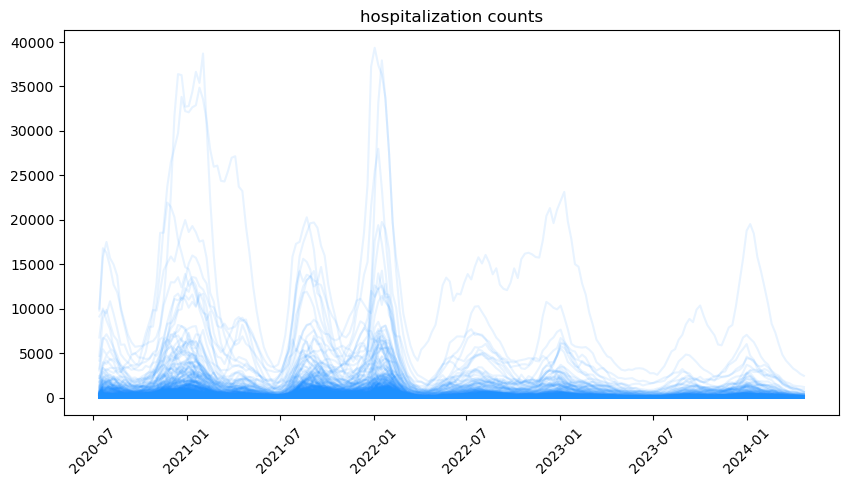

In [4]:
fig, ax = plt.subplots(figsize=(10,5), sharex=True)

for c in tqdm(hosp_df['CBSA'].unique()):
    ax.plot(hosp_df.loc[hosp_df['CBSA'] == c, 'collection_week'], hosp_df.loc[hosp_df['CBSA'] == c, 'total_adult_patients_hospitalized_confirmed_covid_7_day_sum'].values, '-', label='total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_sum', alpha=0.1, color='dodgerblue')

ax.set_title('hospitalization counts')
plt.xticks(rotation=45)

## Advan data

In [5]:
%%time
mobility_df = process_data.get_advan_mobility_data()

CPU times: user 42.6 s, sys: 2.73 s, total: 45.3 s
Wall time: 45.3 s


In [6]:
# mobility_df['date_range_start'] = pd.to_datetime(mobility_df['date_range_start'])
# mobility_df['date_range_end'] = pd.to_datetime(mobility_df['date_range_end'])

# routes = mobility_df.groupby(['cbsa_orig', 'cbsa_dest'])
# num_routes = len(routes)

# # Plot each route
# for idx, ((cbsa_orig, cbsa_dest), route_data) in enumerate(routes):
#     route_data_sorted = route_data.sort_values('date_range_start')
#     color = 'steelblue'
#     ax.plot(
#         route_data_sorted['date_range_start'],
#         route_data_sorted['visitor_home_aggregation'],
#         alpha=0.4,
#         linewidth=0.7,
#         color=color
#     )

# ax.set_xlabel('Date Range Start', fontsize=12)
# ax.set_ylabel('Visitor Home Aggregation', fontsize=12)
# ax.set_title(f'Mobility Time Series by Route\n({num_routes} cbsa_orig × cbsa_dest combinations)', fontsize=14)
# ax.grid(True, alpha=0.3)

# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

## Process data for pytorch-geometric

In [1]:
%%time
import torch
from cgnn import process_data
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("processing data on device:", device)

version = "gcn-usa-hosp-safegraph-2020-22"
data = process_data.create_torch_geometric_data(version, device, include_temporal_edges=True)

/burg/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /burg-archive/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/burg/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /burg-archive/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


processing data on device: cuda


/burg-archive/apam/users/nhw2114/repos/cgnn/src/cgnn/process_data.py:794: DtypeWarning: Columns (0,3) have mixed types. Specify dtype option on import or set low_memory=False.
  hosp_df = pd.read_csv(RAW_HOSPITALZATION_FILE, dtype={"fips_code": str})


number of hospitals with less than max_missing_weeks=21 missing weeks: 4737
unique ZIPs in zip-cbsa map: 39502
unique ZIPs in zip-county map: 39490
num zips in cbsa but not county: 15
num zips in county but not cbsa: 3
creating coo_df
Creating spatial edges...


Spatial Edges: 100%|██████████| 2201651/2201651 [01:15<00:00, 29316.01it/s]


2201651 spatial edges
Creating temporal edges...
129024 temporal edges
processing advan data
Processing edge weights...


100%|██████████| 2330675/2330675 [00:01<00:00, 1316706.67it/s]


Processed data saved to ../data/processed/gcn-usa-hosp-safegraph-2020-22/
CPU times: user 4min 44s, sys: 17.5 s, total: 5min 1s
Wall time: 7min 15s


In [2]:
torch.save(data, f"../data/processed/{version}/data.pt")

In [3]:
# import torch
# from cgnn import process_data

# version = "gcn-usa-hosp-advan-2020-24"
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# data = torch.load(f"../data/processed/{version}/data.pt")
# data = data.to(device)

In [4]:
# import pandas as pd

# version = "gcn-usa-hosp-advan-2020-24"

# df = pd.read_csv(f"../data/processed/{version}/case_data.csv")
# df.groupby("collection_week")["total_adult_patients_hospitalized_confirmed_covid_7_day_sum"].sum().plot()

# data.test_mask.sum()

# Check edges are done properly

In [8]:
with open(f"../data/processed/{version}/node_dict.pkl", "rb") as file:
    node_dict = pickle.load(file)

In [9]:
swapped_node_dict = {value: key for key, value in node_dict.items()}

In [10]:
# for i, edge in tqdm(enumerate(torch.transpose(data.edge_index, 0, 1))):
#     orig_node = swapped_node_dict[edge[0].cpu().numpy().item()]
#     dest_node = swapped_node_dict[edge[1].cpu().numpy().item()]
    
#     orig_fips = orig_node.split("-")[0]
#     dest_fips = dest_node.split("-")[0]
    
#     orig_date = pd.to_datetime("-".join(orig_node.split("-")[1:]))
#     dest_date = pd.to_datetime("-".join(dest_node.split("-")[1:]))
    
#     # check that that if date is diff, then the fips is same and its from old to new
#     if orig_date != dest_date:
#         assert orig_fips == dest_fips, f"temporal edge, {orig_node}, {dest_node} diff fips"
#         assert orig_date < dest_date, f"temporal edge, {orig_node}, {dest_node} wrong direction"
        

In [24]:
data

Data(x=[129920, 1], edge_index=[2, 2330675], y=[129920], edge_weight=[2330675], train_mask=[129920], test_mask=[129920])

# Train model

##  GCN

In [12]:
from cgnn.model import GCN, RMSLELoss
from torch_geometric.nn import summary

graph = data.to(device)
print(graph)

model     = GCN().to(device)
print(summary(model, graph.x, graph.edge_index, graph.edge_weight))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=5e-4)
criterion = RMSLELoss()

def train():
	model.train()
	optimizer.zero_grad()
	out = model(graph.x.to(device), graph.edge_index.to(device), graph.edge_weight.to(device))
	loss = criterion(out[graph.train_mask].squeeze(), graph.y[graph.train_mask])
	loss.backward()
	optimizer.step()
	return loss

def test():
	model.eval()
	out = model(graph.x, graph.edge_index, graph.edge_weight)
	loss = criterion(out[graph.test_mask].squeeze(), graph.y[graph.test_mask])

	return loss

train_loss = []
test_loss = []
for epoch in tqdm(range(5_000)):
	loss = train()
	train_loss.append(loss.cpu().detach().numpy())
	loss = test()
	test_loss.append(loss.cpu().detach().numpy())

print("final test loss: {}".format(test_loss[-1]))

Data(x=[129920, 1], edge_index=[2, 2330675], y=[129920], edge_weight=[2330675], train_mask=[129920], test_mask=[129920])
+---------------------+---------------------------------------+----------------+----------+
| Layer               | Input Shape                           | Output Shape   | #Param   |
|---------------------+---------------------------------------+----------------+----------|
| GCN                 | [129920, 1], [2, 2330675], [2330675]  | [129920, 1]    | 3,265    |
| ├─(MLP_embed)Linear | [129920, 1]                           | [129920, 32]   | 64       |
| ├─(conv1)GCNConv    | [129920, 32], [2, 2330675], [2330675] | [129920, 32]   | 1,056    |
| ├─(conv2)GCNConv    | [129920, 64], [2, 2330675], [2330675] | [129920, 32]   | 2,080    |
| ├─(MLP_pred)Linear  | [129920, 64]                          | [129920, 1]    | 65       |
+---------------------+---------------------------------------+----------------+----------+


100%|██████████| 5000/5000 [03:02<00:00, 27.37it/s]

final test loss: 0.9884453415870667


In [13]:
import os

model_save_dir = f"models/gcn_checkpoints/{version}"
os.makedirs(model_save_dir, exist_ok=True)

model_path = os.path.join(model_save_dir, "gcn_final_model.pt")

torch.save({
    'epoch': 5000, # Or the actual last epoch number
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': train_loss[-1],
    'test_loss': test_loss[-1],
    # You can save other information here, like hyperparameters
}, model_path)

In [14]:
# import torch
# from cgnn.model import GCN, RMSLELoss

# graph = data.to(device)

# model = GCN().to(device)

# model_path = f"models/gcn_checkpoints/{version}/gcn_final_model.pt"
# checkpoint = torch.load(model_path)

# model.load_state_dict(checkpoint['model_state_dict'])

# model.eval()

# print("Model loaded successfully!")


# criterion = RMSLELoss()

In [15]:
model.eval()
out = model(graph.x, graph.edge_index, graph.edge_weight)
print("train loss", criterion(out[graph.train_mask].squeeze(), graph.y[graph.train_mask]))
print("test loss", criterion(out[graph.test_mask].squeeze(), graph.y[graph.test_mask]))
print("train corr", torch.corrcoef(torch.stack((out[graph.train_mask].squeeze(), graph.y[graph.train_mask])))[0,1])
print("test corr", torch.corrcoef(torch.stack((out[graph.test_mask].squeeze(), graph.y[graph.test_mask])))[0,1])
y_test = graph.y[graph.test_mask].cpu().numpy()
out_test = out[graph.test_mask].detach().cpu().numpy()

y_train = graph.y[graph.train_mask].cpu().numpy()
out_train = out[graph.train_mask].detach().cpu().numpy()

train loss tensor(0.9346, device='cuda:0', grad_fn=<SqrtBackward0>)
test loss tensor(0.9884, device='cuda:0', grad_fn=<SqrtBackward0>)
train corr tensor(0.9616, device='cuda:0', grad_fn=<SelectBackward0>)
test corr tensor(0.9815, device='cuda:0', grad_fn=<SelectBackward0>)


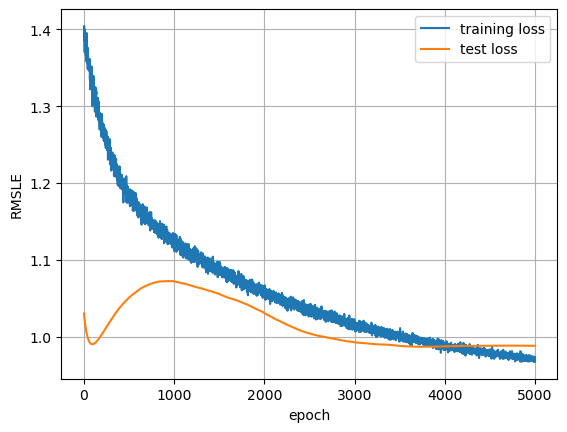

In [16]:
fig, ax = plt.subplots()

ax.plot(train_loss, label='training loss')
ax.plot(test_loss, label='test loss')
ax.set_xlabel('epoch')
ax.set_ylabel('RMSLE')
ax.grid()
ax.legend()

Text(0.5, 1.0, 'Training set')

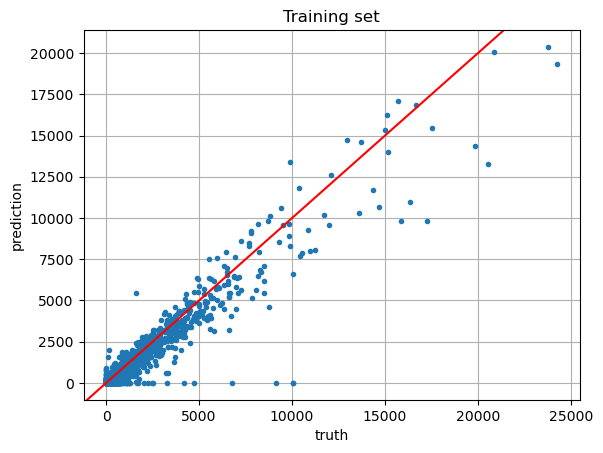

In [17]:
fig, ax = plt.subplots()
ax.plot(y_train, out_train, '.')
ax.axline((0, 0), slope=1., color='red')
ax.grid()
ax.set_xlabel('truth')
ax.set_ylabel('prediction')
ax.set_title('Training set')

Text(0.5, 1.0, 'Test set')

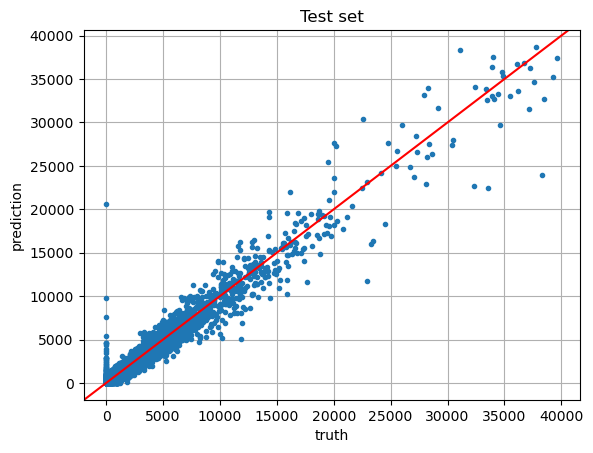

In [18]:
fig, ax = plt.subplots()
ax.plot(y_test, out_test, '.')
ax.axline((0, 0), slope=1., color='red')
ax.grid()
ax.set_xlabel('truth')
ax.set_ylabel('prediction')
ax.set_title('Test set')

In [19]:
with open(f"../data/processed/{version}/node_dict.pkl", "rb") as file:
    node_dict = pickle.load(file)

pred_df = pd.DataFrame()
pred_df['key'] = np.array(list(node_dict.keys()))[np.where(np.array(graph.test_mask.cpu().numpy())==1)]
pred_df['truth'] = y_test
pred_df['pred'] = out_test

pred_df[['cbsa','date']] = pred_df['key'].str.split('-',n=1, expand=True)
pred_df['date'] = pd.to_datetime(pred_df['date'])

train_df = pd.DataFrame()
train_df['key'] = np.array(list(node_dict.keys()))[np.where(np.array(graph.train_mask.cpu().numpy())==1)]
train_df['truth'] = y_train
train_df['pred'] = out_train

train_df[['cbsa','date']] = train_df['key'].str.split('-',n=1, expand=True)
train_df['date'] = pd.to_datetime(train_df['date'])

In [26]:
pred_df

,key,truth,pred,fips,date
0,11180-2020-11-23,237.0,219.857300,11180,2020-11-23
1,33500-2020-11-23,20.0,14.963548,33500,2020-11-23
2,24540-2020-11-23,668.0,618.028687,24540,2020-11-23
3,16580-2020-11-23,144.0,143.711914,16580,2020-11-23
4,23240-2020-11-23,122.0,125.020226,23240,2020-11-23
...,...,...,...,...,...
98555,37740-2022-12-26,0.0,298.059082,37740,2022-12-26
98556,27420-2022-12-26,0.0,587.575195,27420,2022-12-26
98557,45140-2022-12-26,0.0,108.530991,45140,2022-12-26
98558,41700-2022-12-26,0.0,92.579033,41700,2022-12-26


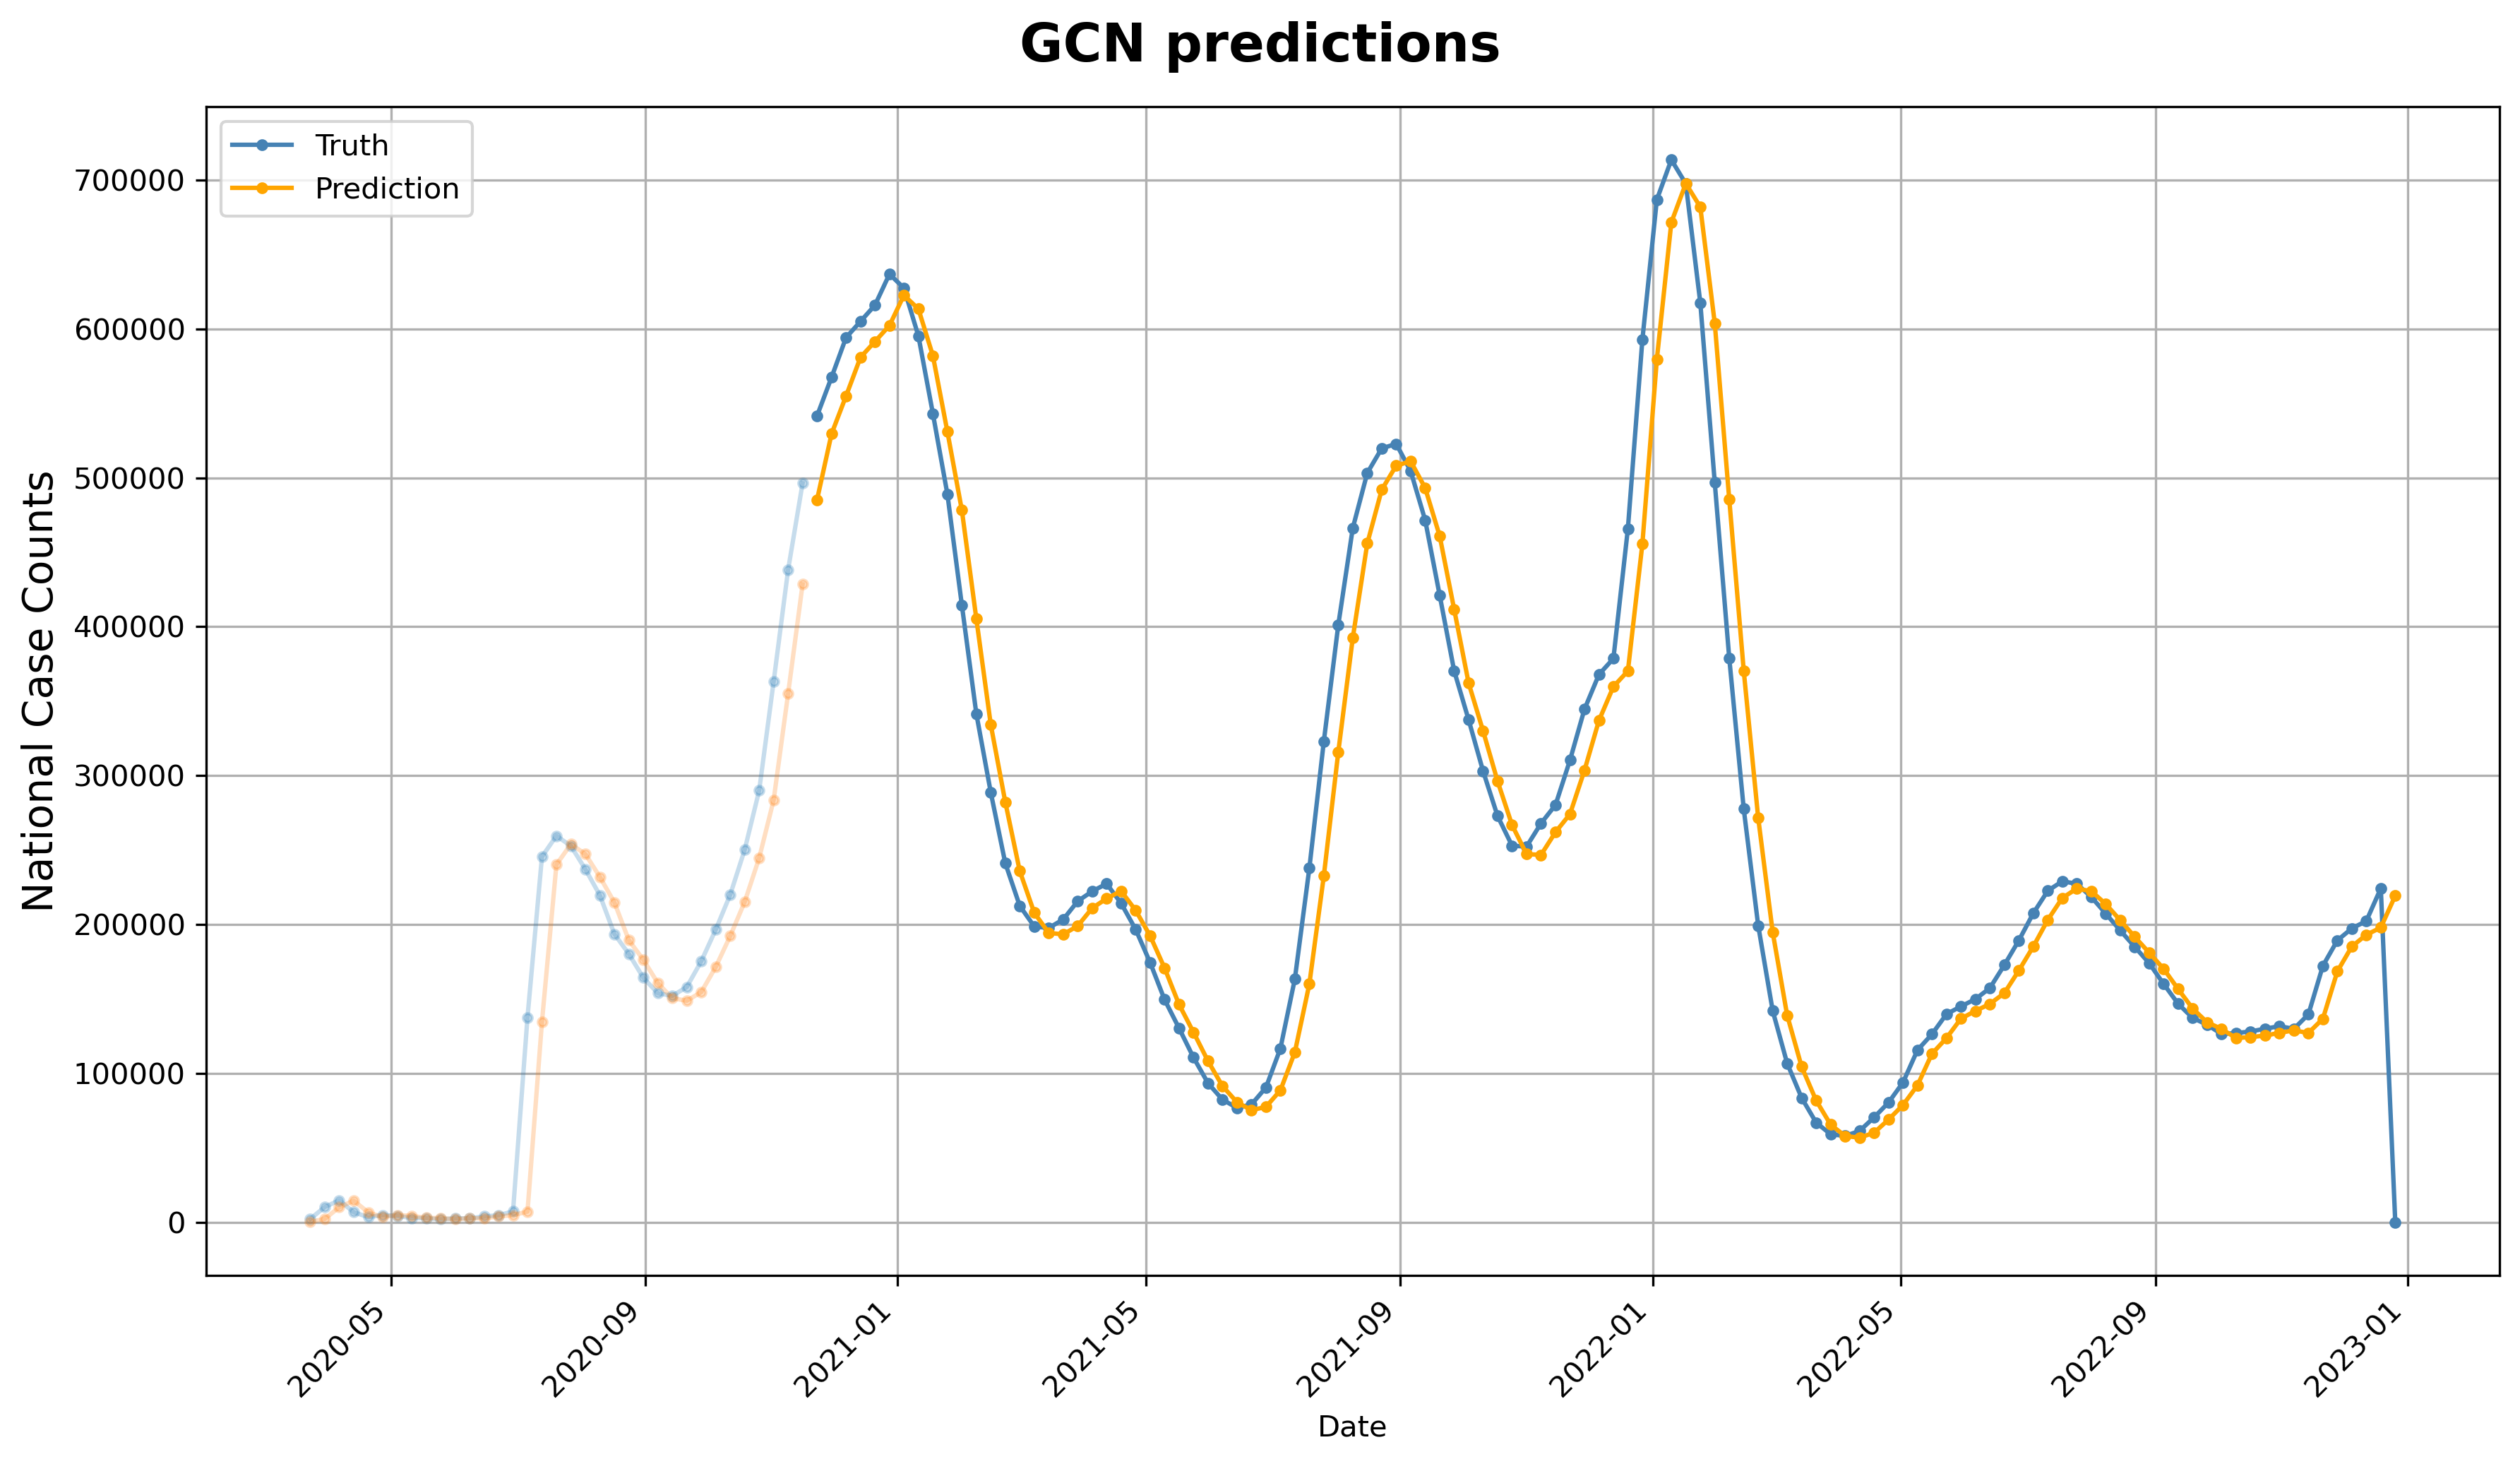

In [20]:
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

ax.plot(train_df.groupby('date')[['truth', 'pred']].sum(), '.-', alpha = 0.25)

ax.plot(pred_df.groupby('date')[['truth']].sum(), '.-', color='steelblue', label='Truth')
ax.plot(pred_df.groupby('date')[['pred']].sum(), '.-', color='orange', label='Prediction')
ax.legend(loc='upper left', fontsize=10)

ax.set_ylabel('National Case Counts', fontsize=14)
ax.set_xlabel('Date')
ax.grid('dashed')

fig.suptitle('GCN predictions',
             fontsize=18,
             fontweight='bold')

fig.autofmt_xdate(rotation=45)
plt.tight_layout()

# GNNExplainer

In [24]:
with open(f"../data/processed/{version}/node_dict.pkl", "rb") as file:
    node_dict = pickle.load(file)

In [25]:
from datetime import datetime

def get_mask(target_date, node_dict, prev_weeks=None):
    # get node_dict
    def get_values_by_date(data_dict, target_date):
        filtered_values = []
        for key, value in data_dict.items():
            if target_date in key:
                filtered_values.append(value)
        return filtered_values
    
    target_idxs = get_values_by_date(node_dict, target_date)
    assert len(target_idxs) > 0, f"target_idxs empty for {target_date}"
    
    target_idxs = torch.tensor(target_idxs).to(device)
    
    # historical_nodes = torch.arange(max(target_idxs), device=device)
    historical_nodes = []
    for node_key, node_idx in node_dict.items():
        date_parts = node_key.split('-')[1:]
        node_date_str = "-".join(date_parts)
        node_date = datetime.strptime(node_date_str, "%Y-%m-%d")
    
        if node_date <= datetime.strptime(target_date, "%Y-%m-%d"):
            if prev_weeks:
                # check that node is within certain number of weeks of target date
                diff = datetime.strptime(target_date, "%Y-%m-%d") - node_date
                if diff.days // 7 <= prev_weeks:
                    historical_nodes.append(node_idx)
            else:
                historical_nodes.append(node_idx)
    historical_nodes = torch.tensor(historical_nodes, dtype=torch.long).to(device)
    
    sub_edge_index, sub_edge_weight  = subgraph(
        subset=historical_nodes,
        edge_index=data.edge_index,
        edge_attr=data.edge_weight,
        relabel_nodes=True,
        return_edge_mask=False
    )
    sub_x = data.x[historical_nodes]

    target_node_map = {original_idx.item(): new_idx for new_idx, original_idx in enumerate(historical_nodes)}
    relabeled_target_idxs = torch.tensor([target_node_map[idx.item()] for idx in target_idxs]).to(device)

    return sub_x, sub_edge_index, sub_edge_weight, relabeled_target_idxs, historical_nodes


def get_explaination(target_date, prev_weeks=None):
    explainer = Explainer(
        model=model.cpu(),
        algorithm=GNNExplainer(epochs=200),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(
            mode='regression',
            task_level='node',
            return_type='raw',
        ),
    )
    # sub_x: data x historical_nodes_idx
    
    sub_x, sub_edge_index, sub_edge_weight, target_idxs, historical_nodes = get_mask(target_date, node_dict, prev_weeks)
    assert all(idx <= sub_x.shape[0] for idx in target_idxs), f"Some target idx out of bounds: {target_idxs}, sub_x.shape={sub_x.shape}"

    explanation = explainer(
        x=sub_x.to("cpu"),
        edge_index=sub_edge_index.to("cpu"),
        edge_weight=sub_edge_weight.to("cpu"),
        index=target_idxs.to("cpu"),
    )
    
    print("average explainable edge mask:", explanation.edge_mask.mean())
    
    subgraph_edges = sub_edge_index[:,explanation.edge_mask > 0.5]
    original_subgraph_edges = historical_nodes.cpu()[subgraph_edges.cpu()]
    
    print("number of edges in edge mask:", original_subgraph_edges.shape[1])
    print("number of self edges:", sum(original_subgraph_edges[0,:] == original_subgraph_edges[1,:]))
    print("number of inter edges:", sum(original_subgraph_edges[0,:] != original_subgraph_edges[1,:]))
    print("number of temporal edges:")

    return explanation, original_subgraph_edges

In [38]:
%%time
mobility_df = process_data.get_advan_mobility_data()

mobility_df['key'] = mobility_df['cbsa_orig'] + "-" + pd.to_datetime(mobility_df['date_range_start']).dt.strftime('%Y-%m-%d') + "-" + \
    mobility_df['cbsa_dest'] + "-" + pd.to_datetime(mobility_df['date_range_end']).dt.strftime('%Y-%m-%d')

# merge lat and long into to mobility df
cbsa_lat_long_df = pd.read_csv('../data/raw/2024_Gaz_cbsa_national.csv', dtype={
        "GEOID": "str",
})

mobility_df = mobility_df.merge(cbsa_lat_long_df[["GEOID", "INTPTLAT", "INTPTLONG"]], left_on="cbsa_orig", right_on="GEOID", how="left").drop("GEOID", axis=1).rename(
    columns={"INTPTLAT":"LATITUDE_orig", "INTPTLONG":"LONGITUDE_orig"}
)

mobility_df = mobility_df.merge(cbsa_lat_long_df[["GEOID", "INTPTLAT", "INTPTLONG"]], left_on="cbsa_dest", right_on="GEOID", how="left").drop("GEOID", axis=1).rename(
    columns={"INTPTLAT":"LATITUDE_dest", "INTPTLONG":"LONGITUDE_dest"}
)

mobility_df["log_visitor_home_aggregation"] = np.log(mobility_df["visitor_home_aggregation"])

mobility_df.head()

CPU times: user 52.5 s, sys: 4.87 s, total: 57.4 s
Wall time: 57.4 s


,cbsa_orig,cbsa_dest,date_range_start,date_range_end,visitor_home_aggregation,key,LATITUDE_orig,LONGITUDE_orig,LATITUDE_dest,LONGITUDE_dest,log_visitor_home_aggregation
0,10100,10100,2020-07-13,2020-07-20,154828,10100-2020-07-13-10100-2020-07-20,45.519435,-98.7007,45.519435,-98.7007,11.950070
1,10100,10100,2020-07-20,2020-07-27,152741,10100-2020-07-20-10100-2020-07-27,45.519435,-98.7007,45.519435,-98.7007,11.936499
2,10100,10100,2020-07-27,2020-08-03,145581,10100-2020-07-27-10100-2020-08-03,45.519435,-98.7007,45.519435,-98.7007,11.888488
3,10100,10100,2020-08-03,2020-08-10,162151,10100-2020-08-03-10100-2020-08-10,45.519435,-98.7007,45.519435,-98.7007,11.996283
4,10100,10100,2020-08-10,2020-08-17,154621,10100-2020-08-10-10100-2020-08-17,45.519435,-98.7007,45.519435,-98.7007,11.948732


In [39]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from shapely.geometry import MultiPolygon, Polygon

def plot_safegraph(subset_df, target_date, land_color='white', tristate_color='#ccebc5', other_state_color='#f0f0f0'):
    """
    Generates a plot of mobility data

    Args:
        subset_df (pd.DataFrame): DataFrame containing mobility data with columns:
                                   'LATITUDE_orig', 'LONGITUDE_orig',
                                   'LATITUDE_dest', 'LONGITUDE_dest',
                                   'log_visitor_home_aggregation'.
        land_color (str): Color for the land masses.
        tristate_color (str): Fill color for NY, NJ, and PA.
        other_state_color (str): Fill color for other states.

    Returns:
        matplotlib.figure.Figure: The generated Matplotlib figure object.
    """
    # Ensure data is sorted for consistent plotting (optional, but can help if overlap matters)
    subset_df = subset_df.sort_values('log_visitor_home_aggregation')

    # --- Figure Setup ---
    fig = plt.figure(figsize=(10, 8), dpi=300)
    platecarree = ccrs.PlateCarree() # Projection for lat/lon data
    geodetic = ccrs.Geodetic()       # Projection for distance calculations (if needed)

    ax = fig.add_subplot(1, 1, 1, projection=platecarree)
    ax.set_extent([-135, -60, 20, 55], platecarree)

    # --- Add Geographic Features ---

    # Add Land with specified color
    ax.add_feature(cfeature.LAND, facecolor=land_color, edgecolor='black', linewidth=0.3, zorder=0)
    ax.add_feature(cfeature.STATES, linewidth=0.8, edgecolor='gray', zorder=5)

    # Add Ocean and Lakes
    ax.add_feature(cfeature.OCEAN, facecolor=cfeature.COLORS['water'], zorder=1)
    # ax.add_feature(cfeature.LAKES, facecolor=cfeature.COLORS['water'], edgecolor='black', linewidth=0.3, zorder=1)

    # Add Coastline
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black', zorder=3)

    # --- Plot Mobility Data ---
    def _plot_row_movement(row, platecarree, geodetic, sm):
        """Plots the movement for a single row of the DataFrame."""
        lat_orig = row['LATITUDE_orig']
        lon_orig = row['LONGITUDE_orig']
        lat_dest = row['LATITUDE_dest']
        lon_dest = row['LONGITUDE_dest']

        # Transform points only if necessary (already in PlateCarree for plotting)
        # lon_orig_proj, lat_orig_proj = platecarree.transform_point(lon_orig, lat_orig, geodetic)
        # lon_dest_proj, lat_dest_proj = platecarree.transform_point(lon_dest, lat_dest, geodetic)

        mob = row['log_visitor_home_aggregation']

        # Check for self-loops (origin == destination)
        # Use a small tolerance for floating point comparison
        if abs(lon_orig - lon_dest) < 1e-6 and abs(lat_orig - lat_dest) < 1e-6:
            ax.plot(lon_orig, lat_orig, marker='o',
                    markerfacecolor='blue', # Color by magnitude
                    markeredgecolor='none', # No edge for cleaner look
                    markersize=np.sqrt(mob), # Scale size non-linearly? Adjust as needed
                    transform=platecarree,
                    alpha=0.7, zorder=5)
        else:
            # Plot movement lines
            color = sm.to_rgba(mob)
            # Scale linewidth (tanh saturates, consider linear or sqrt scaling)
            linewidth = np.sqrt(max(0, mob - subset_df['log_visitor_home_aggregation'].min() + 1)) * 0.5 # Example scaling
            linewidth = max(0.1, linewidth) # Ensure minimum linewidth

            # ax.plot([lon_orig, lon_dest], [lat_orig, lat_dest],
            #          color=color,
            #          linewidth=linewidth,
            #          transform=platecarree,
            #          solid_capstyle='round',
            #          alpha=0.8,
            #          zorder=4)

            ax.annotate(
                '',
                xy=(lon_dest, lat_dest),
                xycoords=platecarree,
                xytext=(lon_orig, lat_orig),
                textcoords=platecarree,
                arrowprops=dict(
                    arrowstyle="->",
                    color=color,
                    lw=linewidth,
                    alpha=0.8,
                    shrinkA=1, shrinkB=5
                ),
                zorder=7,
            )

    # --- Color Mapping for Lines ---
    # Filter out self-loops for normalization if they exist and are handled differently
    non_self_loops = subset_df[
        (abs(subset_df['LATITUDE_orig'] - subset_df['LATITUDE_dest']) > 1e-6) |
        (abs(subset_df['LONGITUDE_orig'] - subset_df['LONGITUDE_dest']) > 1e-6)
    ]

    if not non_self_loops.empty:
        min_val = non_self_loops['log_visitor_home_aggregation'].min()
        max_val = non_self_loops['log_visitor_home_aggregation'].max()
        # Handle case where min and max are the same
        if min_val == max_val:
             norm = plt.Normalize(vmin=min_val - 1, vmax=max_val + 1) # Adjust range slightly
        else:
             norm = plt.Normalize(vmin=min_val, vmax=max_val)

        custom_cmap = plt.cm.viridis # Or choose another perceptually uniform colormap like 'plasma', 'cividis'
        sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
        sm.set_array([]) # Important for standalone colorbar

        # Iterate and plot each movement line
        for index, row in subset_df.iterrows():
            _plot_row_movement(row, platecarree, geodetic, sm)

        # Add Colorbar
        cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04, shrink=0.8)
        cbar.set_label(r'$\log_{10}$ Visitor Home Aggregation', fontsize=10)
        cbar.ax.tick_params(labelsize=8)

    else:
        print("No non-self-loop data to plot lines for.")


    # --- Final Touches ---
    ax.set_title(f"Explainable Subgraph, target_date:{target_date}", fontsize=14, pad=10)

    plt.tight_layout()

    return fig


In [40]:
self_edge_count = []
inter_edge_count = []
PREV_WEEKS = 4

# explain_dates = pd.date_range(start="2020-05-04", end="2022-12-31", freq='W-MON')
explain_dates = pd.date_range(start="2020-07-13", end="2024-04-22", freq='W-MON')

explaination_dict = {}

with PdfPages('explainable_subgraph.pdf') as pdf:
# with PdfPages('test.pdf') as pdf:
    for target_date in tqdm(explain_dates):
        target_date = target_date.strftime('%Y-%m-%d')
        print(target_date)
        explanation, subgraph_edges = get_explaination(target_date, prev_weeks=PREV_WEEKS)
        explaination_dict[target_date] = subgraph_edges
        
        # count types of edges
        self_edge_count.append(sum(subgraph_edges[0,:] == subgraph_edges[1,:]).cpu().numpy())
        inter_edge_count.append(sum(subgraph_edges[0,:] != subgraph_edges[1,:]).cpu().numpy())
    
        # create key
        swapped_dict = {value: key for key, value in node_dict.items()}
        node_idx_start = [swapped_dict[item] for item in subgraph_edges[0,:].cpu().numpy()]
        node_idx_end = [swapped_dict[item] for item in subgraph_edges[1,:].cpu().numpy()]
        explainable_keys = [node_idx_start[i] + "-" + node_idx_end[i] for i in range(len(node_idx_end))]
        explainable_mobility_df = mobility_df[mobility_df["key"].isin(explainable_keys)]
    
        print(explainable_mobility_df.groupby("date_range_start").size())
    
        # plot
        fig = plot_safegraph(explainable_mobility_df, target_date)
        pdf.savefig(fig)
        plt.close(fig)

  0%|          | 0/198 [00:00<?, ?it/s]

2020-07-13
average explainable edge mask: tensor(0.2273)
number of edges in edge mask: 1653
number of self edges: tensor(89)
number of inter edges: tensor(1564)
number of temporal edges:
Series([], dtype: int64)
No non-self-loop data to plot lines for.


  1%|          | 1/198 [00:22<1:13:22, 22.35s/it]

2020-07-20
average explainable edge mask: tensor(0.2196)
number of edges in edge mask: 3092
number of self edges: tensor(157)
number of inter edges: tensor(2935)
number of temporal edges:
date_range_start
2020-07-13    513
dtype: int64
No non-self-loop data to plot lines for.


  1%|          | 2/198 [00:40<1:05:17, 19.99s/it]

...

 99%|█████████▉| 196/198 [34:18<00:17,  8.77s/it]

2024-04-15
average explainable edge mask: tensor(0.0617)
number of edges in edge mask: 344
number of self edges: tensor(4)
number of inter edges: tensor(340)
number of temporal edges:
date_range_start
2024-04-08    211
dtype: int64
No non-self-loop data to plot lines for.


 99%|█████████▉| 197/198 [34:26<00:08,  8.53s/it]

2024-04-22
average explainable edge mask: tensor(0.0632)
number of edges in edge mask: 302
number of self edges: tensor(7)
number of inter edges: tensor(295)
number of temporal edges:
date_range_start
2024-04-15    173
dtype: int64
No non-self-loop data to plot lines for.


100%|██████████| 198/198 [34:34<00:00, 10.48s/it]


In [41]:
len(explain_dates)

198

# GNNExplainer Plots

In [42]:
explain_dates = explain_dates[:len(self_edge_count)]

explain_count_df = pd.DataFrame({
    'date': explain_dates,
    'self_edge_count': self_edge_count,
    'inter_edge_count': inter_edge_count,
})

explain_count_df['total_edge_count'] = explain_count_df['self_edge_count'] + explain_count_df['inter_edge_count']
explain_count_df['prop_self'] = explain_count_df['self_edge_count'] / explain_count_df['total_edge_count']

explain_count_df.head()

,date,self_edge_count,inter_edge_count,total_edge_count,prop_self
0,2020-07-13,89,1564,1653,0.053842
1,2020-07-20,157,2935,3092,0.050776
2,2020-07-27,164,3073,3237,0.050664
3,2020-08-03,178,3168,3346,0.053198
4,2020-08-10,173,3066,3239,0.053412


In [43]:
explain_count_df.to_csv("explain_count.csv", index=False)
# explain_count_df = pd.read_csv("explain_count.csv")

# explain_dates = pd.date_range(start="2020-07-13", end="2020-11-30", freq='W-MON')


In [44]:
explain_count_df['date'] = pd.to_datetime(explain_count_df['date'])


In [60]:
explain_count_df['prop_self'] = explain_count_df['self_edge_count'] / explain_count_df['total_edge_count']


In [69]:
hosp_df = pd.read_csv(f"../data/processed/{version}/case_data.csv")
hosp_df["collection_week"] = pd.to_datetime(hosp_df["collection_week"])
hosp_df.head()

,CBSA,collection_week,total_adult_patients_hospitalized_confirmed_covid_7_day_sum,node_key
0,10100,2020-03-23,0.0,10100-2020-03-23
1,10140,2020-03-23,0.0,10140-2020-03-23
2,10180,2020-03-23,0.0,10180-2020-03-23
3,10220,2020-03-23,0.0,10220-2020-03-23
4,10300,2020-03-23,0.0,10300-2020-03-23


In [70]:
explain_dates

DatetimeIndex(['2020-03-23', '2020-03-30', '2020-04-06', '2020-04-13',
               '2020-04-20', '2020-04-27', '2020-05-04', '2020-05-11',
               '2020-05-18', '2020-05-25', '2020-06-01', '2020-06-08',
               '2020-06-15', '2020-06-22', '2020-06-29', '2020-07-06',
               '2020-07-13', '2020-07-20', '2020-07-27', '2020-08-03',
               '2020-08-10', '2020-08-17', '2020-08-24', '2020-08-31',
               '2020-09-07', '2020-09-14', '2020-09-21', '2020-09-28',
               '2020-10-05', '2020-10-12', '2020-10-19', '2020-10-26',
               '2020-11-02', '2020-11-09', '2020-11-16', '2020-11-23',
               '2020-11-30', '2020-12-07', '2020-12-14', '2020-12-21',
               '2020-12-28'],
              dtype='datetime64[ns]', freq='W-MON')

In [73]:
explain_count_df

,date,self_edge_count,inter_edge_count,temporal_edge_count,total_edge_count,prop_self
0,2020-03-23,0,0,0,0,NaN
1,2020-03-30,0,0,0,0,NaN
2,2020-04-06,0,0,0,0,NaN
3,2020-04-13,0,0,0,0,NaN
4,2020-04-20,0,0,0,0,NaN
5,2020-04-27,0,0,0,0,NaN
6,2020-05-04,0,0,0,0,NaN
7,2020-05-11,0,0,0,0,NaN
8,2020-05-18,0,0,0,0,NaN
9,2020-05-25,0,0,0,0,NaN


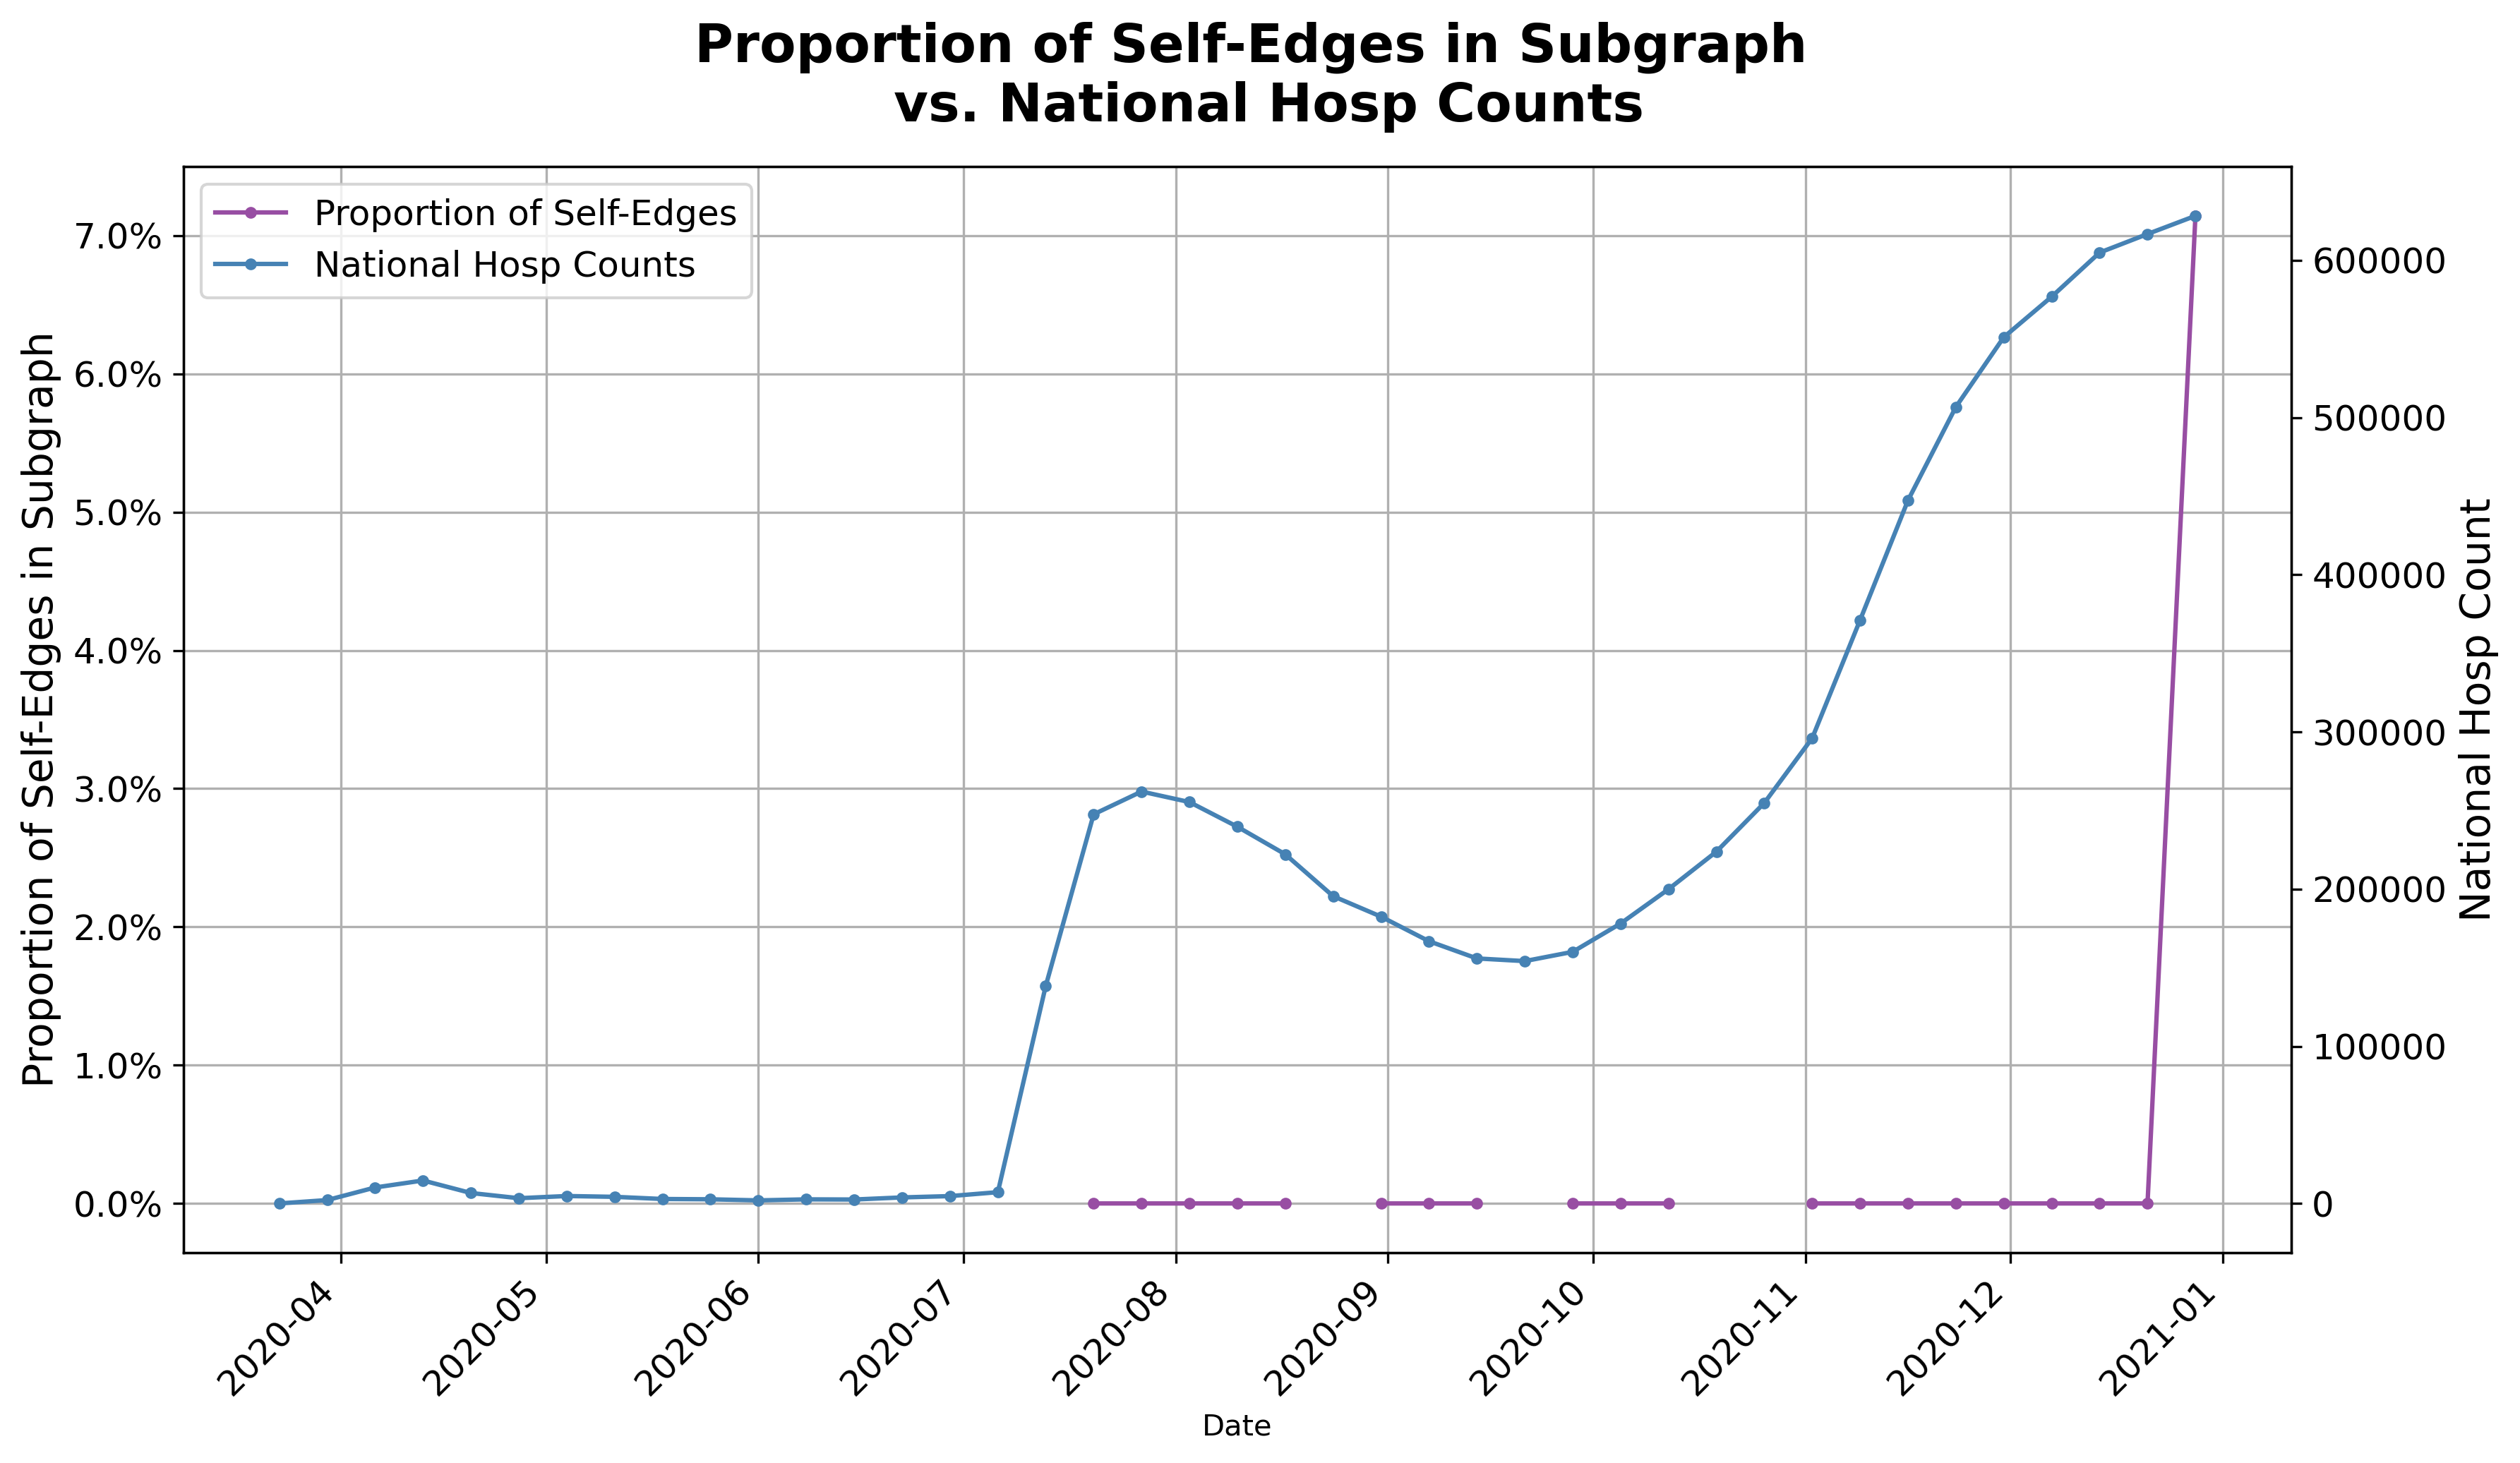

In [72]:
from matplotlib.ticker import PercentFormatter # Import the formatter

fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

hosp_df = hosp_df.loc[hosp_df['collection_week'].isin(explain_dates)].groupby('collection_week')[['total_adult_patients_hospitalized_confirmed_covid_7_day_sum']].sum().reset_index()

line1, = ax.plot(explain_count_df['date'], explain_count_df['prop_self'], '.-', label='Proportion of Self-Edges', color='#984ea3')
ax.set_ylabel('Proportion of Self-Edges in Subgraph', fontsize=14)
ax.set_xlabel('Date')
ax.grid('dashed')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

ax2 = ax.twinx()
line2, = ax2.plot(
    hosp_df['collection_week'],
    hosp_df['total_adult_patients_hospitalized_confirmed_covid_7_day_sum'],
    ".-",
    color='steelblue',
    label='National Hosp Counts' # More descriptive label
)
ax2.set_ylabel('National Hosp Count', fontsize=14)

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelsize=12)

ax.legend(handles=[line1, line2], loc='upper left', fontsize=12)

fig.suptitle('Proportion of Self-Edges in Subgraph \n vs. National Hosp Counts',
             fontsize=18,
             fontweight='bold')


fig.autofmt_xdate(rotation=45)
plt.tight_layout()

# plt.savefig("explain_self_prop.png")


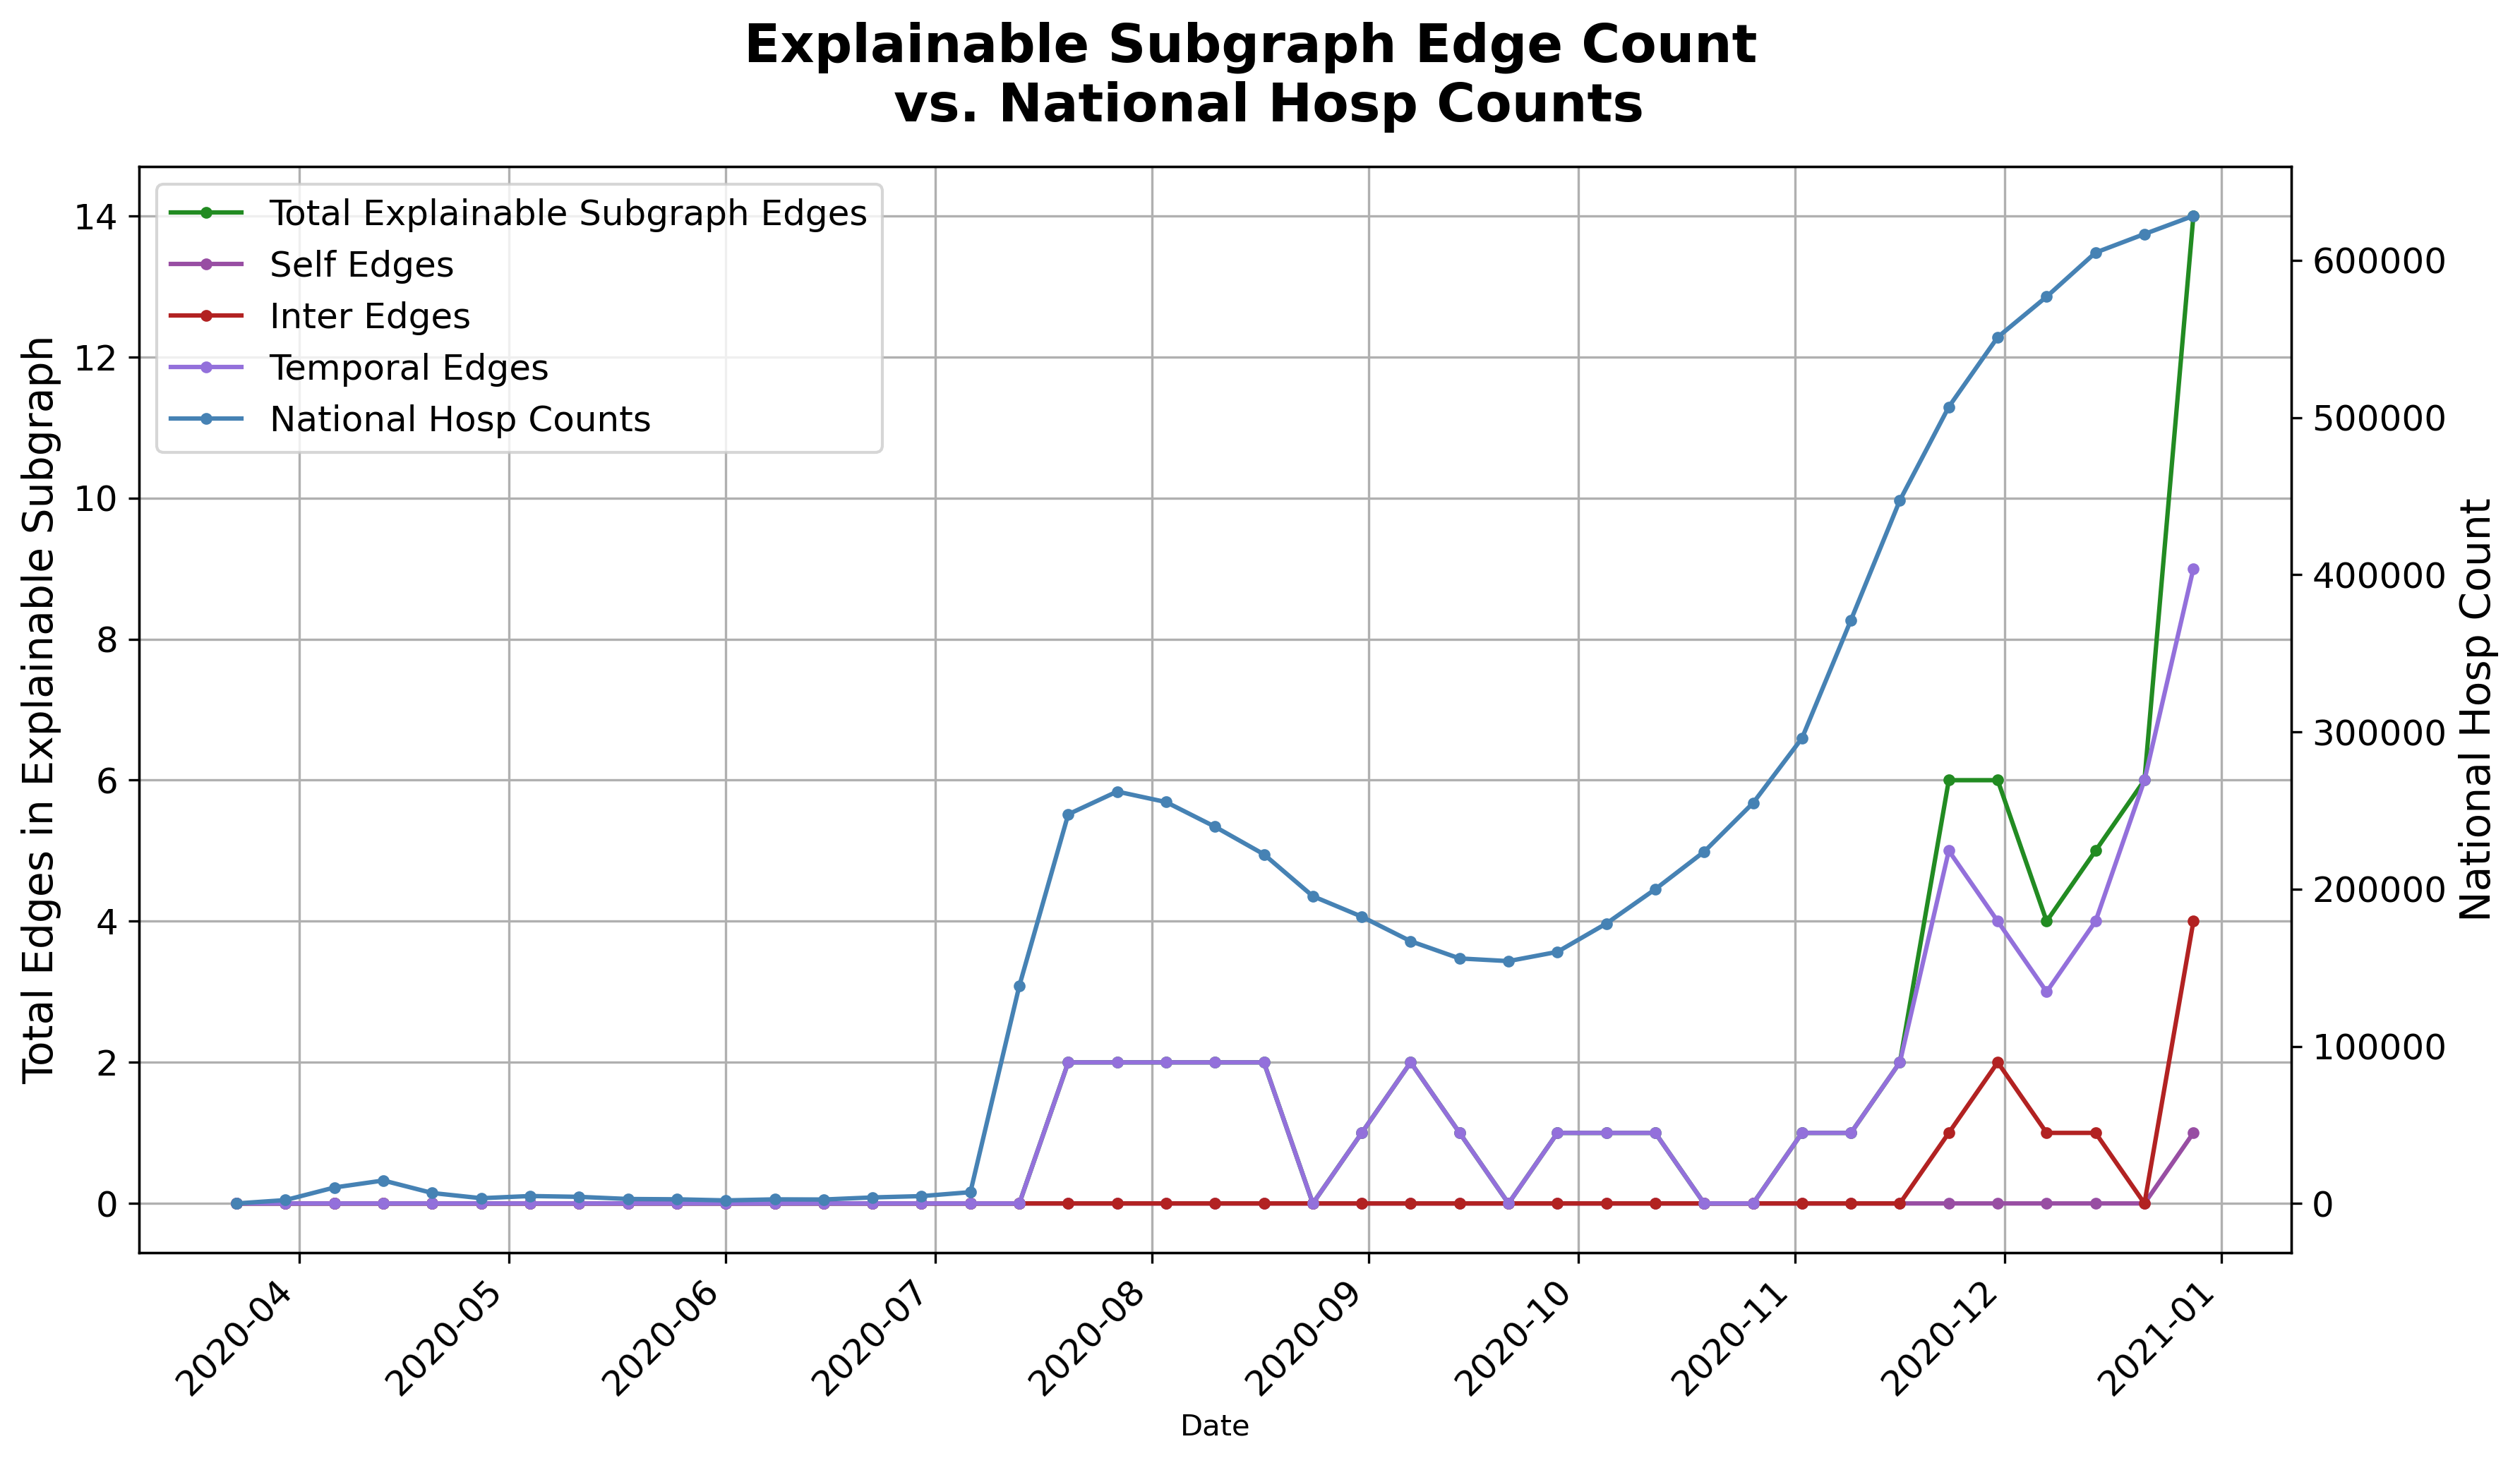

In [75]:
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

line1, = ax.plot(explain_count_df['date'], explain_count_df['total_edge_count'], '.-', label='Total Explainable Subgraph Edges', color='forestgreen')
line2, = ax.plot(explain_count_df['date'], explain_count_df['self_edge_count'], '.-', label='Self Edges', color='#984ea3')
line3, = ax.plot(explain_count_df['date'], explain_count_df['inter_edge_count'], '.-', label='Inter Edges', color='firebrick')
line4, = ax.plot(explain_count_df['date'], explain_count_df['temporal_edge_count'], '.-', label='Temporal Edges', color='mediumpurple')

ax.set_ylabel('Total Edges in Explainable Subgraph', fontsize=14)
ax.set_xlabel('Date')
ax.grid('dashed')

ax2 = ax.twinx()
line5, = ax2.plot(
    hosp_df['collection_week'],
    hosp_df['total_adult_patients_hospitalized_confirmed_covid_7_day_sum'],
    ".-",
    color='steelblue',
    label='National Hosp Counts' # More descriptive label
)
ax2.set_ylabel('National Hosp Count', fontsize=14)

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelsize=12)

ax.legend(handles=[line1, line2, line3, line4, line5], loc='upper left', fontsize=12)


fig.autofmt_xdate(rotation=45)
fig.suptitle('Explainable Subgraph Edge Count \n vs. National Hosp Counts',
             fontsize=18,
             fontweight='bold')

plt.tight_layout()

# plt.savefig("explain_edge_count.png")


In [ ]:
weekly_counts_df = mobility_df.groupby('date_range_start').size().to_frame('weekly_count')
weekly_counts_df['5_week_rolling_sum'] = weekly_counts_df['weekly_count'].rolling(window=5).sum()

start_date = '2020-05-04'
weekly_counts_df = weekly_counts_df.loc[start_date:].copy()
weekly_counts_df

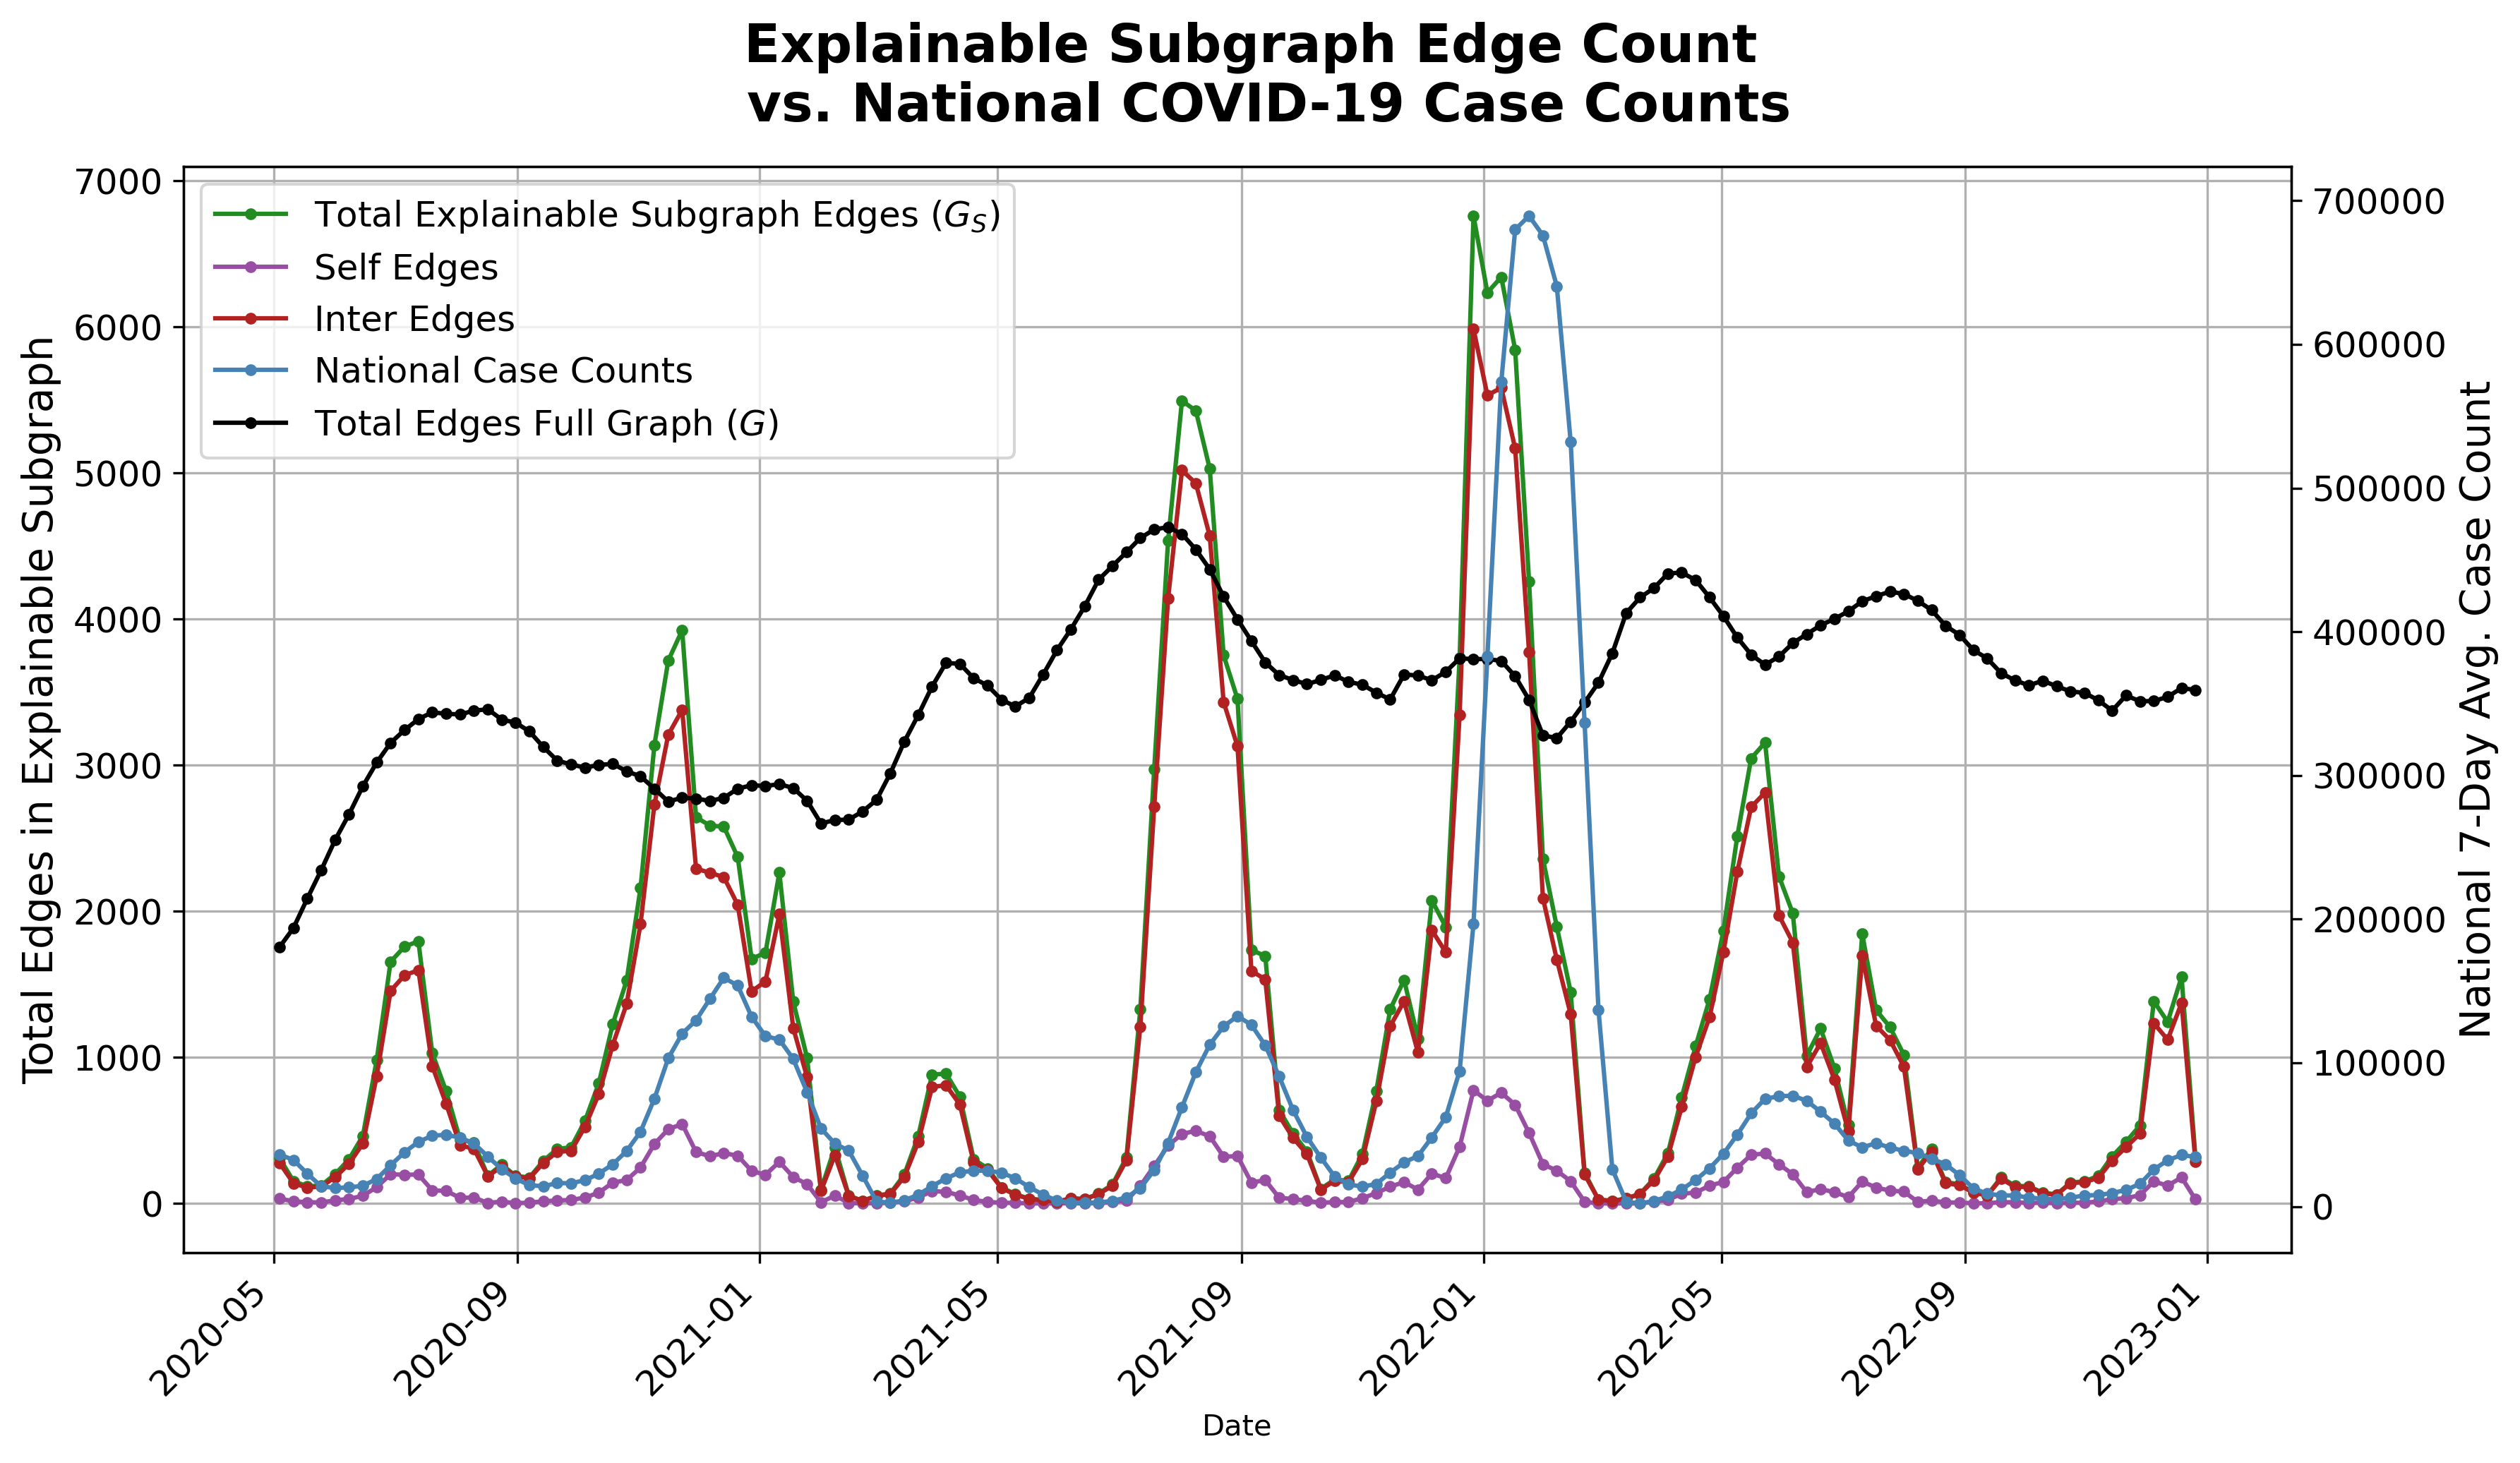

In [35]:
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

sub_case_df = case_df.loc[case_df['date'].isin(explain_dates)].groupby('date')[['CASE_COUNT_7DAY_AVG']].sum().reset_index()

line1, = ax.plot(explain_count_df['date'], explain_count_df['total_edge_count'], '.-', label=r'Total Explainable Subgraph Edges ($G_S$)', color='forestgreen')
line2, = ax.plot(explain_count_df['date'], explain_count_df['self_edge_count'], '.-', label='Self Edges', color='#984ea3')
line3, = ax.plot(explain_count_df['date'], explain_count_df['inter_edge_count'], '.-', label='Inter Edges', color='firebrick')

line5, = ax.plot(weekly_counts_df['5_week_rolling_sum'] / 10, '.-', label=r'Total Edges Full Graph ($G$)', color='black')

ax.set_ylabel('Total Edges in Explainable Subgraph', fontsize=14)
ax.set_xlabel('Date')
ax.grid('dashed')

ax2 = ax.twinx()
line4, = ax2.plot(
    sub_case_df['date'],
    sub_case_df['CASE_COUNT_7DAY_AVG'],
    ".-",
    color='steelblue',
    label='National Case Counts' # More descriptive label
)
ax2.set_ylabel('National 7-Day Avg. Case Count', fontsize=14)

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelsize=12)

ax.legend(handles=[line1, line2, line3, line4, line5], loc='upper left', fontsize=12)


fig.autofmt_xdate(rotation=45)
fig.suptitle('Explainable Subgraph Edge Count \n vs. National COVID-19 Case Counts',
             fontsize=18,
             fontweight='bold')

plt.tight_layout()



--- Computing Autocorrelation for: 'Total Explainable Subgraph Edges' ---
  * Autocorrelation at Lag 1: `0.9143`
    This value indicates the linear relationship between a data point and the data point immediately preceding it.
  * First 5 Autocorrelation Coefficients (including Lag 0, which is always 1):
    - Lag 0: `1.0000`
    - Lag 1: `0.9117`
    - Lag 2: `0.7651`
    - Lag 3: `0.5694`
    - Lag 4: `0.3564`
    - Lag 5: `0.1606`
    Note: The autocorrelation at Lag 0 is always 1, as a series is perfectly correlated with itself.


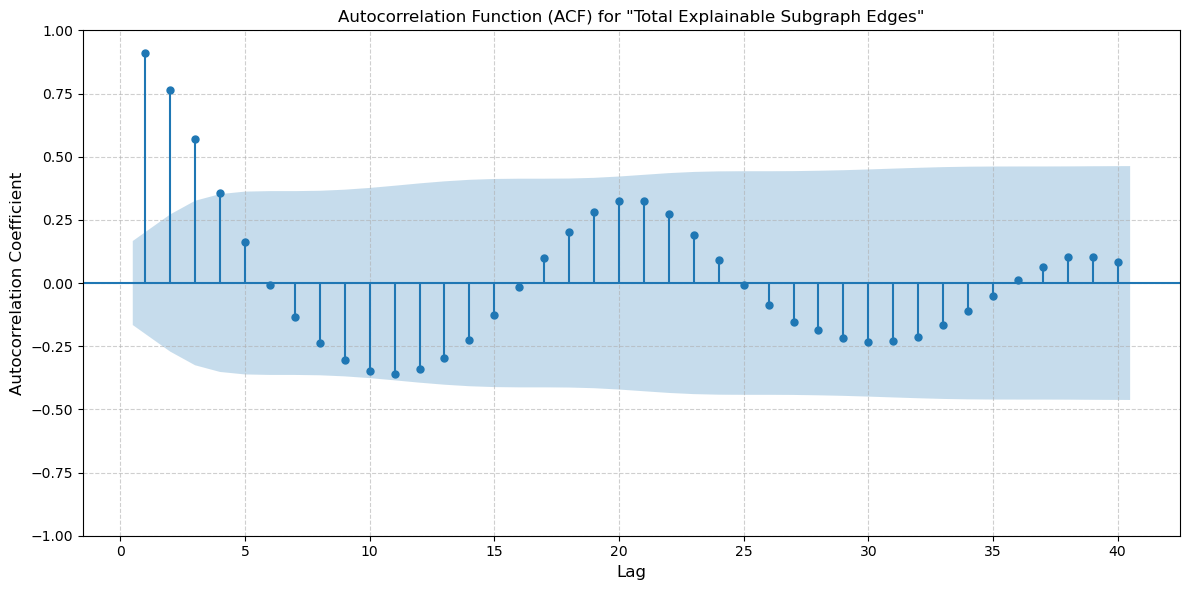


--- Computing Autocorrelation for: 'Self Edges' ---
  * Autocorrelation at Lag 1: `0.9048`
    This value indicates the linear relationship between a data point and the data point immediately preceding it.
  * First 5 Autocorrelation Coefficients (including Lag 0, which is always 1):
    - Lag 0: `1.0000`
    - Lag 1: `0.9026`
    - Lag 2: `0.7551`
    - Lag 3: `0.5610`
    - Lag 4: `0.3571`
    - Lag 5: `0.1688`
    Note: The autocorrelation at Lag 0 is always 1, as a series is perfectly correlated with itself.


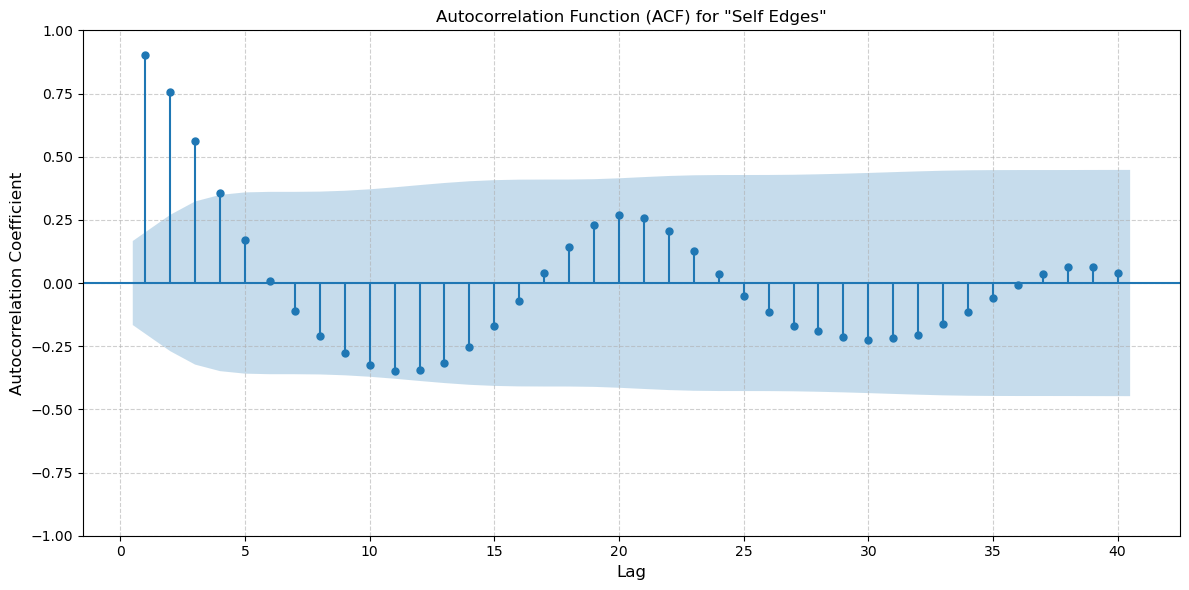


--- Computing Autocorrelation for: 'Inter Edges' ---
  * Autocorrelation at Lag 1: `0.9152`
    This value indicates the linear relationship between a data point and the data point immediately preceding it.
  * First 5 Autocorrelation Coefficients (including Lag 0, which is always 1):
    - Lag 0: `1.0000`
    - Lag 1: `0.9126`
    - Lag 2: `0.7662`
    - Lag 3: `0.5705`
    - Lag 4: `0.3569`
    - Lag 5: `0.1606`
    Note: The autocorrelation at Lag 0 is always 1, as a series is perfectly correlated with itself.


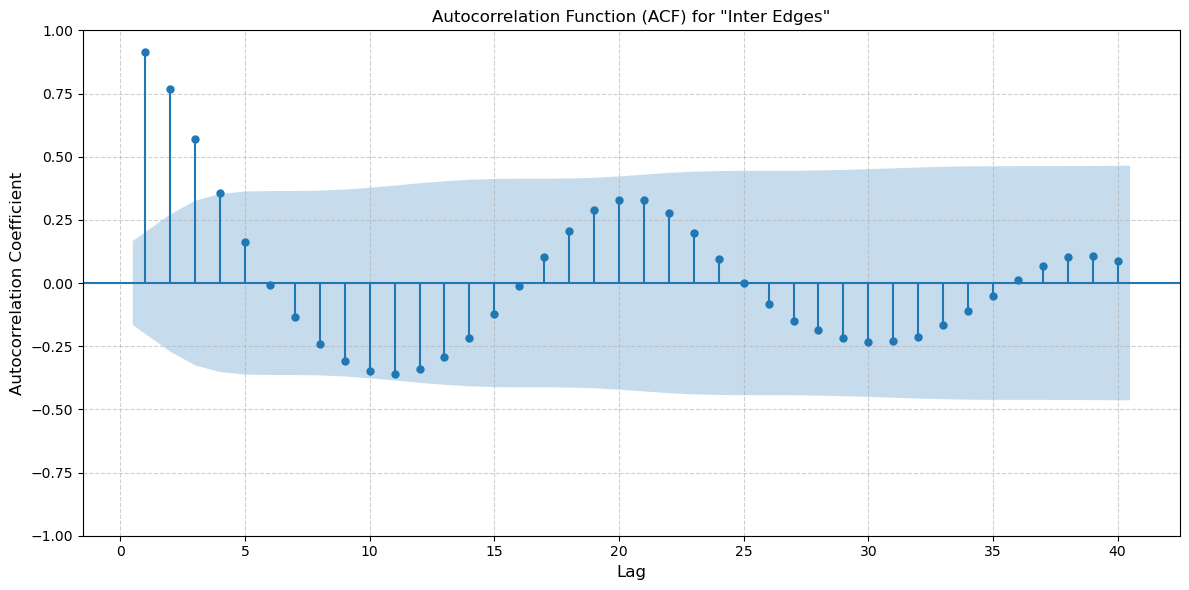


--- Computing Autocorrelation for: 'National 7-Day Avg. Case Count' ---
  * Autocorrelation at Lag 1: `0.9561`
    This value indicates the linear relationship between a data point and the data point immediately preceding it.
  * First 5 Autocorrelation Coefficients (including Lag 0, which is always 1):
    - Lag 0: `1.0000`
    - Lag 1: `0.9555`
    - Lag 2: `0.8362`
    - Lag 3: `0.6704`
    - Lag 4: `0.4847`
    - Lag 5: `0.2991`
    Note: The autocorrelation at Lag 0 is always 1, as a series is perfectly correlated with itself.


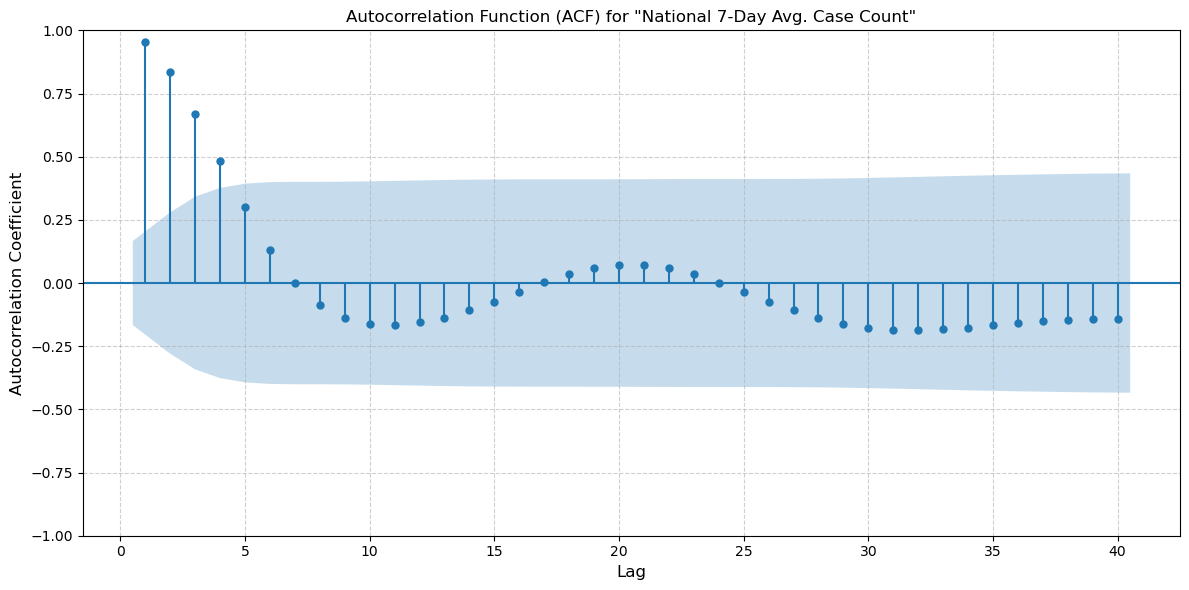

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf # For computing an array of ACF values

# Assuming explain_count_df and sub_case_df are already loaded and available in your Jupyter environment
# from the plotting cell you provided.

# Dictionary to hold the time series we want to analyze.
# We extract the relevant columns directly from your dataframes based on your plot code.
time_series_to_analyze = {
    'Total Explainable Subgraph Edges': explain_count_df['total_edge_count'],
    'Self Edges': explain_count_df['self_edge_count'],
    'Inter Edges': explain_count_df['inter_edge_count'],
    'National 7-Day Avg. Case Count': sub_case_df['CASE_COUNT_7DAY_AVG']
}

for name, series in time_series_to_analyze.items():
    print(f"\n--- Computing Autocorrelation for: '{name}' ---")

    # Before computing, let's check if the series has enough data points.
    if len(series) < 2:
        print(f"  The series '{name}' has only {len(series)} data points, which is too short to compute meaningful autocorrelation. Skipping this series.")
        continue

    # Determine a reasonable number of lags to compute for the ACF.
    # A common rule of thumb is to use `min(len(series) // 2 - 1, 40)` to avoid too many lags for shorter series
    # and to focus on the most relevant lags for longer ones.
    max_lags_for_acf = min(len(series) // 2 - 1, 40)
    if max_lags_for_acf <= 0:
        print(f"  The series '{name}' is too short ({len(series)} data points) to compute multiple lags for autocorrelation. Skipping detailed ACF analysis.")
        continue

    # 1. Compute a specific autocorrelation value (e.g., at lag 1)
    # The `.autocorr(lag=1)` method from pandas Series provides a quick way to get this.
    # This gives you a single number representing the correlation between the series and itself shifted by one period.
    autocorr_lag1 = series.autocorr(lag=1)
    print(f"  * Autocorrelation at Lag 1: `{autocorr_lag1:.4f}`")
    print(f"    This value indicates the linear relationship between a data point and the data point immediately preceding it.")


    # 2. Compute the full Autocorrelation Function (ACF) values
    # The `acf` function from `statsmodels.tsa.stattools` computes an array of autocorrelation coefficients
    # for various lags.
    #   - `nlags`: The number of lags to compute.
    #   - `fft=True`: Can speed up computation for very long series.
    #   - `unbiased=True`: Uses an unbiased estimator for the sample autocorrelation.
    #   - `alpha=0.05`: Used to return confidence intervals, which are helpful for `plot_acf`.
    acf_coefficients, confint = acf(series, nlags=max_lags_for_acf, fft=True, alpha=0.05)

    print(f"  * First 5 Autocorrelation Coefficients (including Lag 0, which is always 1):")
    for i, coeff in enumerate(acf_coefficients[:6]):
        print(f"    - Lag {i}: `{coeff:.4f}`")
    print(f"    Note: The autocorrelation at Lag 0 is always 1, as a series is perfectly correlated with itself.")


    # 3. Visualize the Autocorrelation Function (ACF) plot
    # This is the most common and intuitive way to inspect autocorrelation across many lags.
    # The `plot_acf` function from `statsmodels.graphics.tsaplots` generates this plot.
    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
    plot_acf(series, lags=max_lags_for_acf, ax=ax,
             title=f'Autocorrelation Function (ACF) for "{name}"',
             alpha=0.05, # Alpha for the confidence interval band (typically 95% CI)
             zero=False # Exclude lag 0 from the plot, as it's always 1 and can obscure other lags
            )
    ax.set_xlabel("Lag", fontsize=12)
    ax.set_ylabel("Autocorrelation Coefficient", fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


In [43]:
from scipy import signal


time_series_to_analyze = {
    'Total Explainable Subgraph Edges': explain_count_df['total_edge_count'],
    'Self Edges': explain_count_df['self_edge_count'],
    'Inter Edges': explain_count_df['inter_edge_count'],
}

y = sub_case_df['CASE_COUNT_7DAY_AVG']

for name, x in time_series_to_analyze.items():
    
    correlation = signal.correlate(x-np.mean(x), y - np.mean(y), mode="full")
    lags = signal.correlation_lags(len(x), len(y), mode="full")
    lag = lags[np.argmax(abs(correlation))]
    print(lag)

-3
-3
-3


In [44]:
lags

array([-138, -137, -136, -135, -134, -133, -132, -131, -130, -129, -128,
       -127, -126, -125, -124, -123, -122, -121, -120, -119, -118, -117,
       -116, -115, -114, -113, -112, -111, -110, -109, -108, -107, -106,
       -105, -104, -103, -102, -101, -100,  -99,  -98,  -97,  -96,  -95,
        -94,  -93,  -92,  -91,  -90,  -89,  -88,  -87,  -86,  -85,  -84,
        -83,  -82,  -81,  -80,  -79,  -78,  -77,  -76,  -75,  -74,  -73,
        -72,  -71,  -70,  -69,  -68,  -67,  -66,  -65,  -64,  -63,  -62,
        -61,  -60,  -59,  -58,  -57,  -56,  -55,  -54,  -53,  -52,  -51,
        -50,  -49,  -48,  -47,  -46,  -45,  -44,  -43,  -42,  -41,  -40,
        -39,  -38,  -37,  -36,  -35,  -34,  -33,  -32,  -31,  -30,  -29,
        -28,  -27,  -26,  -25,  -24,  -23,  -22,  -21,  -20,  -19,  -18,
        -17,  -16,  -15,  -14,  -13,  -12,  -11,  -10,   -9,   -8,   -7,
         -6,   -5,   -4,   -3,   -2,   -1,    0,    1,    2,    3,    4,
          5,    6,    7,    8,    9,   10,   11,   

### Explainable subplot animation

In [ ]:
from matplotlib.animation import FuncAnimation


land_color = '#f5f5f5'
geodetic = ccrs.Geodetic()
platecarree = ccrs.PlateCarree()

def update(frame_num, target_date, ax, dates, df, sm, cbar_ax, frame_artists):
    """
    The function that draws each frame of the animation.
    'frame_num' is the frame number, provided by FuncAnimation.
    """
    # Clear artists from the previous frame (arrows and colorbar)
    for artist in frame_artists:
        artist.remove()
    frame_artists.clear()
    
    if cbar_ax:
        cbar_ax.clear()

    # Get the data for the current frame
    current_date = dates[frame_num]
    subset_df = df[df['date_range_start'] == current_date].sort_values('log_visitor_home_aggregation')
    
    if subset_df.empty:
        ax.set_title(f"Explainable Mobility\n{current_date.strftime('%Y-%m-%d')} (No Data)", fontsize=12)
        return ax.artists # Return the list of artists

    # --- Plot Mobility Data for the current frame ---
    for _, row in subset_df.iterrows():
        lon_orig, lat_orig = row['LONGITUDE_orig'], row['LATITUDE_orig']
        lon_dest, lat_dest = row['LONGITUDE_dest'], row['LATITUDE_dest']
        mob = row['log_visitor_home_aggregation']
        color = sm.to_rgba(mob)
        
        # Scale linewidth based on mobility value
        linewidth = np.sqrt(max(0, mob - df['log_visitor_home_aggregation'].min() + 1)) * 0.5
        linewidth = max(0.1, linewidth)

        # Use annotate to draw arrows
        arrow_artist = ax.annotate(
            '',
            xy=(lon_dest, lat_dest),
            xycoords=platecarree,
            xytext=(lon_orig, lat_orig),
            textcoords=platecarree,
            arrowprops=dict(
                arrowstyle="->",
                color=color,
                lw=linewidth,
                alpha=0.8,
                shrinkA=1, shrinkB=5
            ),
            zorder=7,
        )

        frame_artists.append(arrow_artist)

    # --- Update Title and Colorbar ---
    ax.set_title(f"Explainable Subgraph \nTarget date: {target_date} Time slice: {current_date.strftime('%Y-%m-%d')}", fontsize=12)
    
    # Re-draw the colorbar for the current frame
    cbar = plt.colorbar(sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label(r'$\log_{10}$ Visitor Home Aggregation', fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    return frame_artists


# --- Main Loop to Generate Animations ---
swapped_dict = {value: key for key, value in node_dict.items()}

for target_date, subgraph_edges in explaination_dict.items():
    print(f"Processing animation for target_date: {target_date}")

    # Create keys to filter the main mobility dataframe
    node_idx_start = [swapped_dict[item] for item in subgraph_edges[0,:].cpu().numpy()]
    node_idx_end = [swapped_dict[item] for item in subgraph_edges[1,:].cpu().numpy()]
    explainable_keys = [f"{start}-{end}" for start, end in zip(node_idx_start, node_idx_end)]
    explainable_mobility_df = mobility_df[mobility_df["key"].isin(explainable_keys)].copy()
    
    # Convert dates if they are not already datetime objects
    explainable_mobility_df["date_range_start"] = pd.to_datetime(explainable_mobility_df["date_range_start"])
    dates = sorted(explainable_mobility_df["date_range_start"].unique())
    
    if not dates:
        print(f"Skipping {target_date} - no data found.")
        continue

    # --- One-Time Plot Setup ---
    fig = plt.figure(figsize=(12, 8), dpi=200)
    ax = fig.add_subplot(1, 1, 1, projection=platecarree)
    ax.set_extent([-130, -65, 23, 50], platecarree)

    # Add static geographic features
    ax.add_feature(cfeature.LAND, facecolor=land_color, zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor=cfeature.COLORS['water'], zorder=1)
    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black', zorder=3)

    # --- Setup Color Mapping ---
    # Normalize across the entire dataset for this target_date for a consistent colorbar
    min_val = explainable_mobility_df['log_visitor_home_aggregation'].min()
    max_val = explainable_mobility_df['log_visitor_home_aggregation'].max()
    norm = plt.Normalize(vmin=min_val, vmax=max_val)
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])

    # Create an axes for the colorbar so we can clear and redraw it
    cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5]) # [left, bottom, width, height]

    frame_artists = []
    # --- Create and Save the Animation ---
    ani = FuncAnimation(
        fig, 
        update, 
        frames=len(dates), 
        fargs=(target_date, ax, dates, explainable_mobility_df, sm, cbar_ax, frame_artists),
        interval=1000, 
        repeat=False
    )
    
    # Save the animation
    output_filename = f'animation_{target_date}.gif'
    print(f"Saving animation to {output_filename}...")
    ani.save(output_filename, writer='imagemagick')
    print("Save complete.")
    plt.close(fig) # Close the figure to free up memory

In [ ]:
# --- Assume these variables are pre-defined ---
# explaination_dict, node_dict, mobility_df
# case_df: Your DataFrame with CBSA case counts

# --- NEW SETUP: Load CBSA Geometries ---
### Provide the path to the .shp file you downloaded
cbsa_shapefile_path = '../assets/tl_2024_us_cbsa/tl_2024_us_cbsa.shp' 

try:
    cbsa_reader = shpreader.Reader(cbsa_shapefile_path)
    # Create a dictionary mapping CBSA code (GEOID) to its geometry
    # This makes lookups much faster inside the animation loop
    cbsa_geometries = {
        rec.attributes['GEOID']: rec.geometry for rec in cbsa_reader.records()
    }
    print(f"Successfully loaded {len(cbsa_geometries)} CBSA shapes.")
except Exception as e:
    print(f"Error loading shapefile: {e}")
    print("Please ensure the path is correct and the shapefile exists.")
    cbsa_geometries = {} # Set to empty to avoid further errors

# Prepare the case data
# Ensure date column is in datetime format
# The column name 'date' is assumed from your DataFrame snippet
case_df['date_range_start'] = pd.to_datetime(case_df['date'])

# --- Constants ---
land_color = '#f5f5f5'
geodetic = ccrs.Geodetic()
platecarree = ccrs.PlateCarree()


### MODIFIED: Update function now handles heatmap_artists as well
def update(frame_num, ax, dates, target_date, mobility_df, case_df, sm_mobility, sm_cases, 
           cbar_ax_mobility, cbar_ax_cases, arrow_artists, heatmap_artists):
    """
    The function that draws each frame of the animation.
    """
    # Clear artists from the previous frame
    for artist in arrow_artists:
        artist.remove()
    arrow_artists.clear()
    
    ### NEW: Clear heatmap shapes from the previous frame
    for artist in heatmap_artists:
        artist.remove()
    heatmap_artists.clear()
    
    # Clear colorbars
    if cbar_ax_mobility: cbar_ax_mobility.clear()
    if cbar_ax_cases: cbar_ax_cases.clear()

    # --- Get data for the current frame ---
    current_date = dates[frame_num]
    
    # --- 1. Draw the CBSA Heatmap (drawn first, so it's in the background) ---
    case_subset = case_df[case_df['date_range_start'] == current_date]
    if not case_subset.empty and cbsa_geometries:
        for _, row in case_subset.iterrows():
            cbsa_code = str(row['CBSA']) # Ensure CBSA code is a string
            case_count = row['CASE_COUNT_7DAY_AVG']
            
            if cbsa_code in cbsa_geometries:
                geom = cbsa_geometries[cbsa_code]
                color = sm_cases.to_rgba(case_count)
                
                # Add the colored CBSA shape to the map
                shape_artist = ax.add_geometries(
                    [geom], crs=platecarree, facecolor=color,
                    edgecolor='gray', linewidth=0.2, zorder=5
                )
                heatmap_artists.append(shape_artist)

    # --- 2. Draw Mobility Arrows ---
    mobility_subset = mobility_df[mobility_df['date_range_start'] == current_date]
    if not mobility_subset.empty:
        for _, row in mobility_subset.iterrows():
            lon_orig, lat_orig = row['LONGITUDE_orig'], row['LATITUDE_orig']
            lon_dest, lat_dest = row['LONGITUDE_dest'], row['LATITUDE_dest']
            mob = row['log_visitor_home_aggregation']
            color = sm_mobility.to_rgba(mob)
            linewidth = np.sqrt(max(0, mob - mobility_df['log_visitor_home_aggregation'].min() + 1)) * 0.5
            
            arrow_artist = ax.annotate(
                '', xy=(lon_dest, lat_dest), xycoords=platecarree,
                xytext=(lon_orig, lat_orig), textcoords=platecarree,
                arrowprops=dict(
                    arrowstyle="->", color=color, lw=max(0.1, linewidth),
                    alpha=0.8, shrinkA=1, shrinkB=5
                ),
                zorder=7, # Higher zorder to draw on top of the heatmap
            )
            arrow_artists.append(arrow_artist)

    # --- 3. Update Titles and Colorbars ---
    ax.set_title(f"Explainable Subgraph \nTarget date: {target_date} Time slice: {current_date.strftime('%Y-%m-%d')}", fontsize=12)

    # Redraw mobility colorbar
    cbar_mob = plt.colorbar(sm_mobility, cax=cbar_ax_mobility, orientation='vertical')
    cbar_mob.set_label(r'$\log_{10}$ Visitor Aggregation', fontsize=10)
    cbar_mob.ax.tick_params(labelsize=8)
    
    # Redraw cases colorbar
    cbar_case = plt.colorbar(sm_cases, cax=cbar_ax_cases, orientation='vertical')
    cbar_case.set_label('7-Day Avg Case Count', fontsize=10)
    cbar_case.ax.tick_params(labelsize=8)

    cbar_case.ax.yaxis.set_ticks_position('left')
    cbar_case.ax.yaxis.set_label_position('left')

    return arrow_artists + heatmap_artists


# --- Main Loop ---
swapped_dict = {value: key for key, value in node_dict.items()}

for target_date, subgraph_edges in explaination_dict.items():
    print(f"Processing animation for target_date: {target_date}")

    node_idx_start = [swapped_dict[item] for item in subgraph_edges[0,:].cpu().numpy()]
    node_idx_end = [swapped_dict[item] for item in subgraph_edges[1,:].cpu().numpy()]
    explainable_keys = [f"{start}-{end}" for start, end in zip(node_idx_start, node_idx_end)]
    explainable_mobility_df = mobility_df[mobility_df["key"].isin(explainable_keys)].copy()
    explainable_mobility_df["date_range_start"] = pd.to_datetime(explainable_mobility_df["date_range_start"])
    dates = sorted(explainable_mobility_df["date_range_start"].unique())
    
    if not dates:
        print(f"Skipping {target_date} - no data found.")
        continue

    # --- One-Time Plot Setup ---
    fig = plt.figure(figsize=(14, 8), dpi=200)
    ax = fig.add_subplot(1, 1, 1, projection=platecarree)
    ax.set_extent([-130, -65, 23, 50], platecarree)
    ax.add_feature(cfeature.LAND, facecolor=land_color, zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor=cfeature.COLORS['water'], zorder=1)
    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black', zorder=3)

    # --- Setup Color Mapping for BOTH datasets ---
    # Mobility Color Scale
    norm_mob = plt.Normalize(vmin=explainable_mobility_df['log_visitor_home_aggregation'].min(), 
                             vmax=explainable_mobility_df['log_visitor_home_aggregation'].max())
    sm_mobility = plt.cm.ScalarMappable(cmap='viridis', norm=norm_mob)
    sm_mobility.set_array([])

    # Cases Color Scale (using LogNorm for better visualization of outbreaks)
    # Using a small epsilon to avoid log(0)
    norm_cases = plt.Normalize(vmin=case_df['CASE_COUNT_7DAY_AVG'].min(), 
                               vmax=case_df['CASE_COUNT_7DAY_AVG'].max())
    sm_cases = plt.cm.ScalarMappable(cmap='Reds', norm=norm_cases)
    sm_cases.set_array([])

    # --- Setup Axes for TWO Colorbars ---
    cbar_ax_mobility = fig.add_axes([0.91, 0.25, 0.02, 0.5])
    cbar_ax_cases = fig.add_axes([0.07, 0.25, 0.02, 0.5])

    # --- Create lists to hold artists for each frame ---
    arrow_artists = []
    heatmap_artists = [] ### NEW list for heatmap shapes

    # --- Create Animation ---
    ani = FuncAnimation(
        fig, 
        update, 
        frames=len(dates), 
        fargs=(ax, dates, target_date, explainable_mobility_df, case_df, sm_mobility, sm_cases,
               cbar_ax_mobility, cbar_ax_cases, arrow_artists, heatmap_artists),
        interval=100, 
        repeat=False
    )
    
    output_filename = f'animation_with_heatmap_{target_date}.gif'
    print(f"Saving animation to {output_filename}...")
    ani.save(output_filename) 
    print("Save complete.")
    plt.close(fig)